C:\Users\Dellpc\anaconda3\Lib\site-packages\scipy\stats\_qmc.py:763: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sample = self._random(n, workers=workers)


Dimensions de vos tenseurs PINN Sobol :
 -> X_i : (150, 3)  |  Poids W_i : (150, 1)
 -> X_b : (80, 3)  |  Poids W_b : (80, 1)
 -> X0  : (40, 3)  |  Poids W0  : (40, 1)


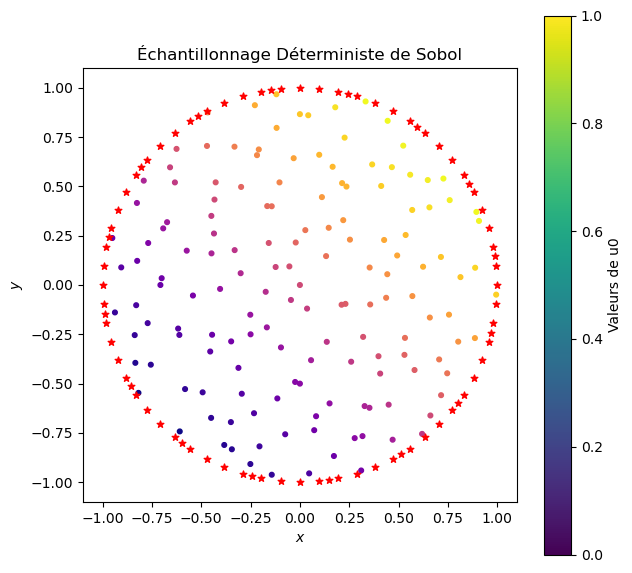

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc  # Contient le générateur de Sobol officiel
import os
import random
from time import time

# ==============================
# Fixer la reproductibilité
# ==============================
SEED = 42          # vous pouvez changer ce nombre

os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'      # important pour TensorFlow
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'    # si vous utilisez le GPU

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Optionnel mais recommandé (force plus de déterminisme)
tf.config.experimental.enable_op_determinism()

DTYPE = "float32"
tf.keras.backend.set_floatx(DTYPE)

# ==============================================================================
# VOS NOTATIONS ET PARAMÈTRES STRICTS
# ==============================================================================
Ni = 150   # Exactement 150 points intérieurs espace-temps
Nb = 80    # Exactement 80 points sur le bord espace-temps
N0 = 40    # Exactement 50 points initiaux à t = 0

# Domaine temporel
tmin, tmax = 0., 1.
volume_total = np.pi * (tmax - tmin)

# Définition des CI adaptées à la solution exacte u(x, y, t) = 2*arctan(e^{x+y+t}) à t=0
def u0(x, y): 
    return 2.0 * tf.math.atan(tf.math.exp(x + y))

# ==============================================================================
# 1. GÉNÉRATION DE L'INTÉRIEUR (X_i) VIA SOBOL 3D (x, y, t)
# ==============================================================================
# On initialise le moteur Sobol pour la dimension d=3
sampler_i = qmc.Sobol(d=3, scramble=False) # scramble=False garantit un déterminisme pur
# On tire exactement Ni points dans [0, 1]^3
sobol_samples_i = sampler_i.random(n=Ni)

# Transformation vers le cylindre espace-temps
r_i_val = np.sqrt(sobol_samples_i[:, 0])      # Racine pour l'homogénéité radiale
theta_i_val = 2 * np.pi * sobol_samples_i[:, 1] # Étalement angulaire uniforme
t_i_val = tmin + (tmax - tmin) * sobol_samples_i[:, 2]

x_i_val = r_i_val * np.cos(theta_i_val)
y_i_val = r_i_val * np.sin(theta_i_val)

X_i = tf.constant(np.stack([x_i_val, y_i_val, t_i_val], axis=1), dtype=DTYPE)

# CALCUL DES POIDS STRICTS POUR L'ESTIMATION D'ERREUR
# Tous les poids sont identiques dans Quasi-Monte Carlo
W_i = tf.constant(np.full((Ni, 1), volume_total / Ni), dtype=DTYPE)

# ==============================================================================
# 2. GÉNÉRATION DU BORD (X_b) VIA SOBOL 2D (theta, t) car r=1 est figé
# ==============================================================================
sampler_b = qmc.Sobol(d=2, scramble=False)
sobol_samples_b = sampler_b.random(n=Nb)

theta_b_val = 2 * np.pi * sobol_samples_b[:, 0]
t_b_val = tmin + (tmax - tmin) * sobol_samples_b[:, 1]

x_b_val = np.cos(theta_b_val)
y_b_val = np.sin(theta_b_val)

X_b = tf.constant(np.stack([x_b_val, y_b_val, t_b_val], axis=1), dtype=DTYPE)

# Poids du bord (Périmètre du cercle * Temps / Nb)
surface_bord = 2 * np.pi * (tmax - tmin)
W_b = tf.constant(np.full((Nb, 1), surface_bord / Nb), dtype=DTYPE)

# ==============================================================================
# 3. GÉNÉRATION DES CONDITIONS INITIALES (X0, X0b) VIA SOBOL 2D (r, theta) car t=0 est figé
# ==============================================================================
sampler_0 = qmc.Sobol(d=2, scramble=False)
sobol_samples_0 = sampler_0.random(n=N0)

r_0_val = np.sqrt(sobol_samples_0[:, 0])
theta_0_val = 2 * np.pi * sobol_samples_0[:, 1]

x_0_val = r_0_val * np.cos(theta_0_val)
y_0_val = r_0_val * np.sin(theta_0_val)
t_0_val = np.zeros(N0)

X0 = tf.constant(np.stack([x_0_val, y_0_val, t_0_val], axis=1), dtype=DTYPE)

# Version projetée sur le bord strict à t=0 (X0b)
x_0b_val = np.cos(theta_0_val)
y_0b_val = np.sin(theta_0_val)
X0b = tf.constant(np.stack([x_0b_val, y_0b_val, t_0_val], axis=1), dtype=DTYPE)

# Poids initiaux (Aire du disque / N0)
W0 = tf.constant(np.full((N0, 1), np.pi / N0), dtype=DTYPE)

# --- Évaluations et extractions ---
x_i = X_i[:, 0:1]
y_i = X_i[:, 1:2]
x_b = X_b[:, 0:1]
y_b = X_b[:, 1:2]

u_i0 = u0(x_i, y_i)

# --- Affichage des dimensions strictes ---
print(f"Dimensions de vos tenseurs PINN Sobol :")
print(f" -> X_i : {X_i.shape}  |  Poids W_i : {W_i.shape}")
print(f" -> X_b : {X_b.shape}  |  Poids W_b : {W_b.shape}")
print(f" -> X0  : {X0.shape}  |  Poids W0  : {W0.shape}")

# Visualisation (Projection spatiale plane)
fig = plt.figure(figsize=(7, 7))
plt.scatter(x_i.numpy(), y_i.numpy(), c=u_i0.numpy(), marker='.', cmap='plasma', s=45)
plt.scatter(x_b.numpy(), y_b.numpy(), c='red', marker='*', s=25)
plt.title("Échantillonnage Déterministe de Sobol")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.gca().set_aspect('equal')
plt.colorbar(label="Valeurs de u0")
plt.show()


In [3]:
# import tensorflow as tf

# def NN(n_layers=6, n_neurons=100):
#     model = tf.keras.Sequential()
#     model.add(tf.keras.Input(shape=(3,)))  # (x,y,t)

#     for _ in range(n_layers):
#         model.add(tf.keras.layers.Dense(
#             n_neurons,
#             activation='swish',
#             kernel_initializer='glorot_normal'
#         ))

#     model.add(tf.keras.layers.Dense(2))  # (u, v)
#     return model
# model = NN()
# model.summary()

In [4]:
import tensorflow as tf
import tensorflow_probability as tfp  # <-- AJOUT IMPORT L-BFGS
import numpy as np                   # <-- AJOUT IMPORT NUMPY SI ABSENT ICI

def NN(n_layers=8, n_neurons=120):
    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=(3,)))  # (x,y,t)

    for _ in range(n_layers):
        model.add(tf.keras.layers.Dense(
            n_neurons,
            activation='tanh',
            kernel_initializer='glorot_normal'
        ))

    model.add(tf.keras.layers.Dense(2))  # (u, v)
    return model

model = NN()
model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 120)               480       
                                                                 
 dense_1 (Dense)             (None, 120)               14520     
                                                                 
 dense_2 (Dense)             (None, 120)               14520     
                                                                 
 dense_3 (Dense)             (None, 120)               14520     
                                                                 
 dense_4 (Dense)             (None, 120)               14520     
                                                                 
 dense_5 (Dense)             (None, 120)               14520     
                                                                 
 dense_6 (Dense)             (None, 120)               1

In [5]:
model = NN()

def compute_uv(model, X):
    uv = model(X)
    u = uv[:, 0:1]
    v = uv[:, 1:2]
    return u, v

def R1(model, X):

    with tf.GradientTape() as tape:
        tape.watch(X)

        u, v = compute_uv(model, X)

    grad_u = tape.gradient(u, X)

    u_t = grad_u[:, 2:3]

    return u_t - v


def R2(model, X):

    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(X)

        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch(X)

            u, v = compute_uv(model, X)

        grad_u = tape1.gradient(u, X)
        grad_v = tape1.gradient(v, X)

        u_x = grad_u[:, 0:1]
        u_y = grad_u[:, 1:2]
        v_t = grad_v[:, 2:3]

    u_xx = tape2.gradient(u_x, X)[:, 0:1]
    u_yy = tape2.gradient(u_y, X)[:, 1:2]
    
    # Coordinates
    x = X[:, 0:1]
    y = X[:, 1:2]
    t = X[:, 2:3]

    source1 = -1/2*tf.sin(2*u)

    return v_t - u_xx - u_yy - source1


def R3(model, X):
    with tf.GradientTape() as tape:
        tape.watch(X)
        r1 = R1(model, X)
    
    grad_r1 = tape.gradient(r1, X)
    return grad_r1[:, 0:2]         # (∂_x R1, ∂_y R1)



def Rb2(model, X):

    with tf.GradientTape() as tape:
        tape.watch(X)

        u, v = compute_uv(model, X)

    grad_u = tape.gradient(u, X)

    u_t = grad_u[:, 2:3]

    return u_t - v






def Rb1(model, X):

    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(X)

        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch(X)

            u, v = compute_uv(model, X)

        # First derivatives
        grad_u = tape1.gradient(u, X)
        grad_v = tape1.gradient(v, X)

        u_x = grad_u[:, 0:1]
        u_y = grad_u[:, 1:2]
        v_t = grad_v[:, 2:3]

    # Second derivatives
    grad_ux = tape2.gradient(u_x, X)
    grad_uy = tape2.gradient(u_y, X)

    u_xx = grad_ux[:, 0:1]
    u_xy = grad_ux[:, 1:2]

    u_yx = grad_uy[:, 0:1]
    u_yy = grad_uy[:, 1:2]

    # Coordinates
    x = X[:, 0:1]
    y = X[:, 1:2]
    t = X[:, 2:3]

    # Source term
    u_ex = 2*tf.atan(tf.exp(x+y+t))
    source2 = 2*(x+y)*tf.sin(u)+x*y*tf.sin(2*u)

    # Boundary residual
    return (
        v_t
        - (
            y**2*u_xx
            - x*y*u_yx
            - x*y*u_xy
            + x**2*u_yy
        )
        + 2*(x*u_x
        + y*u_y)
        - source2
    )



def Rb3(model, X):
    with tf.GradientTape() as tape:
        tape.watch(X)
        rb2 = Rb2(model, X)
    
    grad_rb2 = tape.gradient(rb2, X)[:, 0:2]   # ∇_x,y rb2
    
    n = X[:, 0:2]                              # normale (x,y)
    dnu = tf.reduce_sum(grad_rb2 * n, axis=1, keepdims=True)
    
    return grad_rb2 - dnu * n                  # ∇_Γ rb2



def R_00(model, X):
    u, v = compute_uv(model, X) 
    u0 = 2*tf.atan(tf.exp(X[:,0:1]+X[:,1:2]))
    return u - u0

def R_02(model, X):
    """
    R_02 = ∇ R_00   (gradient spatial)
    Retourne un tenseur de shape (N, 2)
    """
    with tf.GradientTape() as tape:
        tape.watch(X)
        r00 = R_00(model, X)
    
    grad_r00 = tape.gradient(r00, X)
    return grad_r00[:, 0:2]          # (∂x R_00, ∂y R_00)





def R_03(model, X):
    """
    R_03 = ∇_Γ R_00 = ∇R_00 - (∂_ν R_00) n
    Retourne un tenseur de shape (N, 2)
    """
    with tf.GradientTape() as tape:
        tape.watch(X)
        r00 = R_00(model, X)
    
    grad_r00 = tape.gradient(r00, X)[:, 0:2]   # ∇_x,y R_00
    
    n = X[:, 0:2]                              # normale (x, y) sur le cercle unité
    dnu = tf.reduce_sum(grad_r00 * n, axis=1, keepdims=True)  # ∂_ν R_00
    
    return grad_r00 - dnu * n                  # gradient tangentiel




def R_01(model, X):
    u, v = compute_uv(model, X)
    v0 = 2*tf.exp(X[:,0:1]+X[:,1:2])/(1+tf.exp(2*(X[:,0:1]+X[:,1:2])))
    return v - v0








# # Gradient residual
# # ∇u_exact - ∇u_theta
# # =========================================================
# def R_grad(model, X):

#     with tf.GradientTape() as tape:
#         tape.watch(X)

#         u, v = compute_uv(model, X)

#     grad_u = tape.gradient(u, X)

#     u_x = grad_u[:, 0:1]
#     u_y = grad_u[:, 1:2]

#     # Coordinates
#     x = X[:, 0:1]
#     y = X[:, 1:2]
#     t = X[:, 2:3]

#     # Exact gradients
#     u_x_exact = (
#         tf.exp(-t)
#         * tf.cos(x)
#         * tf.sin(y)
#     )

#     u_y_exact = (
#         tf.exp(-t)
#         * tf.sin(x)
#         * tf.cos(y)
#     )

#     Rx = u_x_exact - u_x
#     Ry = u_y_exact - u_y

#     return Rx, Ry



# # =========================================================
# # Time derivative residual
# # u_t_exact - u_t_theta
# # =========================================================
# def R_t(model, X):

#     with tf.GradientTape() as tape:
#         tape.watch(X)

#         u, v = compute_uv(model, X)

#     grad_u = tape.gradient(u, X)

#     u_t = grad_u[:, 2:3]

#     # Coordinates
#     x = X[:, 0:1]
#     y = X[:, 1:2]
#     t = X[:, 2:3]

#     # Exact time derivative
#     u_t_exact = (
#         -tf.exp(-t)
#         * tf.sin(x)
#         * tf.sin(y)
#     )

#     return u_t_exact - u_t


In [6]:
def compt_loss(model):
    r1=tf.reduce_mean(tf.square(R1(model, X_i)))
    r2=tf.reduce_mean(tf.square(R2(model, X_i)))
    r3=tf.reduce_mean(tf.square(R_00(model, X0)))
    r4=tf.reduce_mean(tf.square(R_01(model, X0)))
    r5=tf.reduce_mean(tf.square(R_00(model, X0b)))
    r6=tf.reduce_mean(tf.square(R_01(model, X0b)))
    r7=tf.reduce_mean(tf.square(Rb1(model, X_b)))
    r8=tf.reduce_mean(tf.square(Rb2(model, X_b)))
    r9=tf.reduce_mean(tf.square(R3(model, X_i)))
    r10=tf.reduce_mean(tf.square(Rb3(model, X_b)))
    r11=tf.reduce_mean(tf.square(R_02(model, X0)))
    r12=tf.reduce_mean(tf.square(R_03(model, X0b)))

    
    loss_fun = r1+r2+r3+r4+r5+r6+r7+r8+2*r9+2*r10+2*r11+r12
    return loss_fun


In [7]:
def comp_loss(model):
    r1=tf.reduce_mean(tf.square(R1(model, X_i)))
    r2=tf.reduce_mean(tf.square(R2(model, X_i)))
    r3=tf.reduce_mean(tf.square(R_00(model, X0)))
    r4=tf.reduce_mean(tf.square(R_01(model, X0)))
    r5=tf.reduce_mean(tf.square(R_00(model, X0b)))
    r6=tf.reduce_mean(tf.square(R_01(model, X0b)))
    r7=tf.reduce_mean(tf.square(Rb1(model, X_b)))
    r8=tf.reduce_mean(tf.square(Rb2(model, X_b)))
    r9=tf.reduce_mean(tf.square(R3(model, X_i)))
    r10=tf.reduce_mean(tf.square(Rb3(model, X_b)))
    r11=tf.reduce_mean(tf.square(R_02(model, X0)))
    r12=tf.reduce_mean(tf.square(R_03(model, X0b)))
    rint=r1+r2+r9
    rsb=r7+r8+r10
    rtb=r3+r4+r5+r6+r11+r12
    loss = r1+r2+r3+r4+r5+r6+r7+r8+2*r9+2*r10+2*r11+r12
    return loss, rint, rsb, rtb


In [8]:
loss, rint, rsb, rtb = comp_loss(model)

print(f"Rint      : {rint.numpy():.6e}")
print(f"Rsb             : {rsb.numpy():.6e}")          
print(f"Rtb             : {rtb.numpy():.6e}")
print(f"Total loss        : {loss.numpy():.6e}")

Rint      : 2.761779e-01
Rsb             : 2.271738e-01
Rtb             : 8.729203e+00
Total loss        : 1.015340e+01


In [9]:
def get_grad(model):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(model.trainable_variables)
        loss_fun=compt_loss(model)
    g=tape.gradient(loss_fun, model.trainable_variables)
    del tape
    return loss_fun, g






In [10]:

def get_grad(model):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(model.trainable_variables)
        loss_fun = compt_loss(model)
    g = tape.gradient(loss_fun, model.trainable_variables)
    del tape
    return loss_fun, g

import tensorflow_probability as tfp

def lbfgs_factory_pure(model, get_grad_fn, X_interior, X_boundary, step_counter, hist_list, histories_dict):
    """
    Interfaces TensorFlow parameters with the pure L-BFGS routine from iteration 0.
    """
    trainable_variables = model.trainable_variables
    shapes = [v.shape for v in trainable_variables]
    intervals = []
    start = 0
    for shape in shapes:
        size = np.prod(shape)
        intervals.append((start, start + size))
        start += size

    def assign_weights_from_1d(weights_1d):
        weights_1d = tf.cast(weights_1d, tf.float32)
        for i, shape in enumerate(shapes):
            start, end = intervals[i]
            w = tf.reshape(weights_1d[start:end], shape)
            trainable_variables[i].assign(w)

    @tf.function
    def value_and_gradients_function(weights_1d):
        assign_weights_from_1d(weights_1d)
        loss_fun, grads = get_grad_fn(model)
        grads_1d = tf.concat([tf.reshape(g, [-1]) for g in grads], axis=0)
        return loss_fun, grads_1d

    def optimized_wrapper(weights_1d):
        loss_value, grads_1d = value_and_gradients_function(weights_1d)
        
        hist_list.append(loss_value.numpy())
        
        step_counter[0] += 1
        iter_num = step_counter[0]
        
        # Evaluates relative metrics and prints updates every 100 iterations
        if iter_num % 100 == 0:
            L2_u_i, Linf_u_i, MSE_u_i, L2_v_i, Linf_v_i, MSE_v_i, H1_u_i, H1_v_i = compute_errors_on_points(model, X_interior)
            L2_u_b, Linf_u_b, MSE_u_b, L2_v_b, Linf_v_b, MSE_v_b, H1_u_b, H1_v_b = compute_errors_on_points(model, X_boundary)
            
            histories_dict['epochs'].append(iter_num)
            
            histories_dict['hist_L2_u_i'].append(L2_u_i); histories_dict['hist_Linf_u_i'].append(Linf_u_i); histories_dict['hist_MSE_u_i'].append(MSE_u_i); histories_dict['hist_H1_u_i'].append(H1_u_i)
            histories_dict['hist_L2_v_i'].append(L2_v_i); histories_dict['hist_Linf_v_i'].append(Linf_v_i); histories_dict['hist_MSE_v_i'].append(MSE_v_i); histories_dict['hist_H1_v_i'].append(H1_v_i)
            
            histories_dict['hist_L2_u_b'].append(L2_u_b); histories_dict['hist_Linf_u_b'].append(Linf_u_b); histories_dict['hist_MSE_u_b'].append(MSE_u_b); histories_dict['hist_H1_u_b'].append(H1_u_b)
            histories_dict['hist_L2_v_b'].append(L2_v_b); histories_dict['hist_Linf_v_b'].append(Linf_v_b); histories_dict['hist_MSE_v_b'].append(MSE_v_b); histories_dict['hist_H1_v_b'].append(H1_v_b)
            
            print(f"L-BFGS Iter {iter_num:05d} | Loss={loss_value.numpy():.3e} | L2(u)_int={L2_u_i:.2e} | H1(u)_int={H1_u_i:.2e}")
            
        return loss_value, grads_1d

    return optimized_wrapper


In [11]:
def compute_errors_on_points(model, X):
    """
    Calcule les erreurs relatives (L2, Linf, MSE, H1 Espace-Temps) pour u et v sur un ensemble de points X
    """
    # 1. Calcul des prédictions et de TOUS leurs gradients (Espace + Temps) via un tape persistant
    with tf.GradientTape(persistent=True) as tape:
        tape.watch(X)
        uv = model(X)
        u_tf = uv[:, 0:1]
        v_tf = uv[:, 1:2]
        
    grad_u = tape.gradient(u_tf, X)
    grad_v = tape.gradient(v_tf, X)
    del tape # Libération de la mémoire du tape persistant
    
    # Gradients numériques pour u
    u_x_pred = grad_u[:, 0:1].numpy().flatten()
    u_y_pred = grad_u[:, 1:2].numpy().flatten()
    u_t_pred = grad_u[:, 2:3].numpy().flatten()
    
    # Gradients numériques pour v
    v_x_pred = grad_v[:, 0:1].numpy().flatten()
    v_y_pred = grad_v[:, 1:2].numpy().flatten()
    v_t_pred = grad_v[:, 2:3].numpy().flatten()
    
    # Conversion des prédictions u, v en numpy
    u_pred = u_tf.numpy().flatten()
    v_pred = v_tf.numpy().flatten()
    
    # Extraction des coordonnées
    x = X[:, 0:1].numpy()
    y = X[:, 1:2].numpy()
    t = X[:, 2:3].numpy()
    
    # 2. Solutions exactes analytiques (u, v et leurs gradients)
    exp_term = np.exp(x + y + t)
    denom = 1 + np.exp(2 * (x + y + t))
    
    u_exact = (2 * np.arctan(exp_term)).flatten()
    v_exact = (2 * exp_term / denom).flatten()
    
    # Dérivées premières de u exactes (égales à v)
    u_x_exact = v_exact.copy()
    u_y_exact = v_exact.copy()
    u_t_exact = v_exact.copy()
    
    # Dérivées premières de v exactes : 2*exp*(1 - exp^2) / (1 + exp^2)^2
    v_grad_exact = (2 * exp_term * (1 - np.exp(2 * (x + y + t))) / (denom**2)).flatten()
    v_x_exact = v_grad_exact.copy()
    v_y_exact = v_grad_exact.copy()
    v_t_exact = v_grad_exact.copy()
    
    # 3. Calcul des écarts (erreurs absolues)
    err_u  = u_pred - u_exact
    err_v  = v_pred - v_exact
    
    err_ux = u_x_pred - u_x_exact
    err_uy = u_y_pred - u_y_exact
    err_ut = u_t_pred - u_t_exact
    
    err_vx = v_x_pred - v_x_exact
    err_vy = v_y_pred - v_y_exact
    err_vt = v_t_pred - v_t_exact
    
    # 4. Calcul des métriques standards (L2, Linf, MSE)
    L2_u   = np.sqrt(np.sum(err_u**2)) / (np.sqrt(np.sum(u_exact**2)) + 1e-12)
    Linf_u = np.max(np.abs(err_u))     / (np.max(np.abs(u_exact)) + 1e-12)
    MSE_u  = np.mean(err_u**2)         / (np.mean(u_exact**2) + 1e-12)
    
    L2_v   = np.sqrt(np.sum(err_v**2)) / (np.sqrt(np.sum(v_exact**2)) + 1e-12)
    Linf_v = np.max(np.abs(err_v))     / (np.max(np.abs(v_exact)) + 1e-12)
    MSE_v  = np.mean(err_v**2)         / (np.mean(v_exact**2) + 1e-12)
    
    # 5. Calcul de la norme H1 espace-temps relative pour u
    num_H1_u = np.sum(err_u**2) + np.sum(err_ux**2) + np.sum(err_uy**2) + np.sum(err_ut**2)
    den_H1_u = np.sum(u_exact**2) + np.sum(u_x_exact**2) + np.sum(u_y_exact**2) + np.sum(u_t_exact**2)
    H1_u     = np.sqrt(num_H1_u) / (np.sqrt(den_H1_u) + 1e-12)
    
    # 6. Calcul de la norme H1 espace-temps relative pour v
    num_H1_v = np.sum(err_v**2) + np.sum(err_vx**2) + np.sum(err_vy**2) + np.sum(err_vt**2)
    den_H1_v = np.sum(v_exact**2) + np.sum(v_x_exact**2) + np.sum(v_y_exact**2) + np.sum(v_t_exact**2)
    H1_v     = np.sqrt(num_H1_v) / (np.sqrt(den_H1_v) + 1e-12)
    
    return L2_u, Linf_u, MSE_u, L2_v, Linf_v, MSE_v, H1_u, H1_v




In [12]:
def lbfgs_factory_extended(model, get_grad_fn, X_interior, X_boundary, step_counter, hist_list, histories_dict):
    """
    Fait la passerelle entre TensorFlow et L-BFGS, tout en calculant
    les erreurs relatives à chaque itération pour vos graphiques.
    """
    trainable_variables = model.trainable_variables
    shapes = [v.shape for v in trainable_variables]
    intervals = []
    start = 0
    for shape in shapes:
        size = np.prod(shape)
        intervals.append((start, start + size))
        start += size

    def assign_weights_from_1d(weights_1d):
        weights_1d = tf.cast(weights_1d, tf.float32)
        for i, shape in enumerate(shapes):
            start, end = intervals[i]
            w = tf.reshape(weights_1d[start:end], shape)
            trainable_variables[i].assign(w)

    @tf.function
    def value_and_gradients_function(weights_1d):
        assign_weights_from_1d(weights_1d)
        loss_fun, grads = get_grad_fn(model)
        grads_1d = tf.concat([tf.reshape(g, [-1]) for g in grads], axis=0)
        return loss_fun, grads_1d

    def optimized_wrapper(weights_1d):
        loss_value, grads_1d = value_and_gradients_function(weights_1d)
        
        # Enregistre la loss globale
        hist_list.append(loss_value.numpy())
        
        # Incrémentation correcte de l'élément dans la liste mutable
        step_counter[0] += 1
        iter_num = step_counter[0]
        
        # Calcule et stocke les erreurs toutes les 100 itérations
        if iter_num % 100 == 0:
            L2_u_i, Linf_u_i, MSE_u_i, L2_v_i, Linf_v_i, MSE_v_i, H1_u_i, H1_v_i = compute_errors_on_points(model, X_interior)
            L2_u_b, Linf_u_b, MSE_u_b, L2_v_b, Linf_v_b, MSE_v_b, H1_u_b, H1_v_b = compute_errors_on_points(model, X_boundary)
            
            histories_dict['epochs'].append(iter_num)
            
            histories_dict['hist_L2_u_i'].append(L2_u_i); histories_dict['hist_Linf_u_i'].append(Linf_u_i); histories_dict['hist_MSE_u_i'].append(MSE_u_i); histories_dict['hist_H1_u_i'].append(H1_u_i)
            histories_dict['hist_L2_v_i'].append(L2_v_i); histories_dict['hist_Linf_v_i'].append(Linf_v_i); histories_dict['hist_MSE_v_i'].append(MSE_v_i); histories_dict['hist_H1_v_i'].append(H1_v_i)
            
            histories_dict['hist_L2_u_b'].append(L2_u_b); histories_dict['hist_Linf_u_b'].append(Linf_u_b); histories_dict['hist_MSE_u_b'].append(MSE_u_b); histories_dict['hist_H1_u_b'].append(H1_u_b)
            histories_dict['hist_L2_v_b'].append(L2_v_b); histories_dict['hist_Linf_v_b'].append(Linf_v_b); histories_dict['hist_MSE_v_b'].append(MSE_v_b); histories_dict['hist_H1_v_b'].append(H1_v_b)
            
            print(f"L-BFGS Iter {iter_num:05d} | Loss={loss_value.numpy():.3e} | L2(u)_int={L2_u_i:.2e} | H1(u)_int={H1_u_i:.2e}")
            
        return loss_value, grads_1d

    return optimized_wrapper



--- Initializing Pure L-BFGS Optimization Framework ---
L-BFGS Iter 00100 | Loss=1.837e-03 | L2(u)_int=1.41e-03 | H1(u)_int=5.91e-03
L-BFGS Iter 00200 | Loss=2.755e-04 | L2(u)_int=6.64e-04 | H1(u)_int=2.11e-03
L-BFGS Iter 00300 | Loss=5.401e-05 | L2(u)_int=2.81e-04 | H1(u)_int=9.47e-04
L-BFGS Iter 00400 | Loss=2.147e-05 | L2(u)_int=2.75e-04 | H1(u)_int=7.60e-04
L-BFGS Iter 00500 | Loss=1.255e-05 | L2(u)_int=1.67e-04 | H1(u)_int=6.01e-04
L-BFGS Iter 00600 | Loss=7.875e-06 | L2(u)_int=1.36e-04 | H1(u)_int=4.41e-04
L-BFGS Iter 00700 | Loss=4.991e-06 | L2(u)_int=7.93e-05 | H1(u)_int=2.81e-04
L-BFGS Iter 00800 | Loss=3.292e-06 | L2(u)_int=7.28e-05 | H1(u)_int=2.88e-04
L-BFGS Iter 00900 | Loss=2.796e-06 | L2(u)_int=6.50e-05 | H1(u)_int=2.51e-04
L-BFGS Iter 01000 | Loss=2.223e-06 | L2(u)_int=5.08e-05 | H1(u)_int=1.97e-04
L-BFGS Iter 01100 | Loss=1.818e-06 | L2(u)_int=4.89e-05 | H1(u)_int=1.64e-04
L-BFGS Iter 01200 | Loss=1.661e-06 | L2(u)_int=3.45e-05 | H1(u)_int=1.41e-04
L-BFGS Iter 01300 |

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



L-BFGS finalized in 553.90 s. Convergence flag: False
Final minimized objective loss reached: 1.761e-07


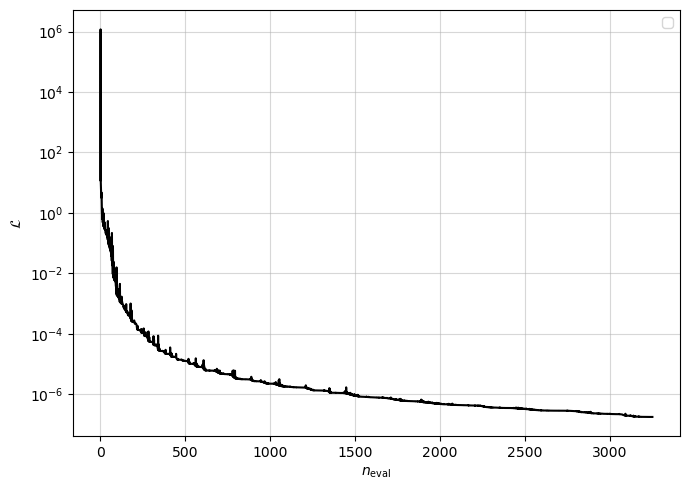

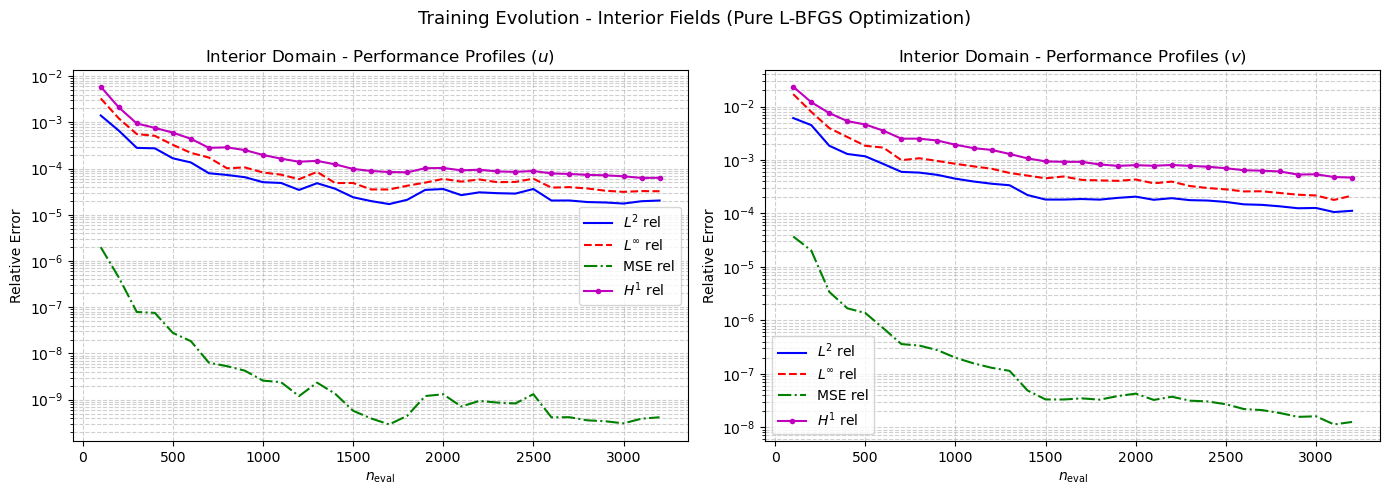

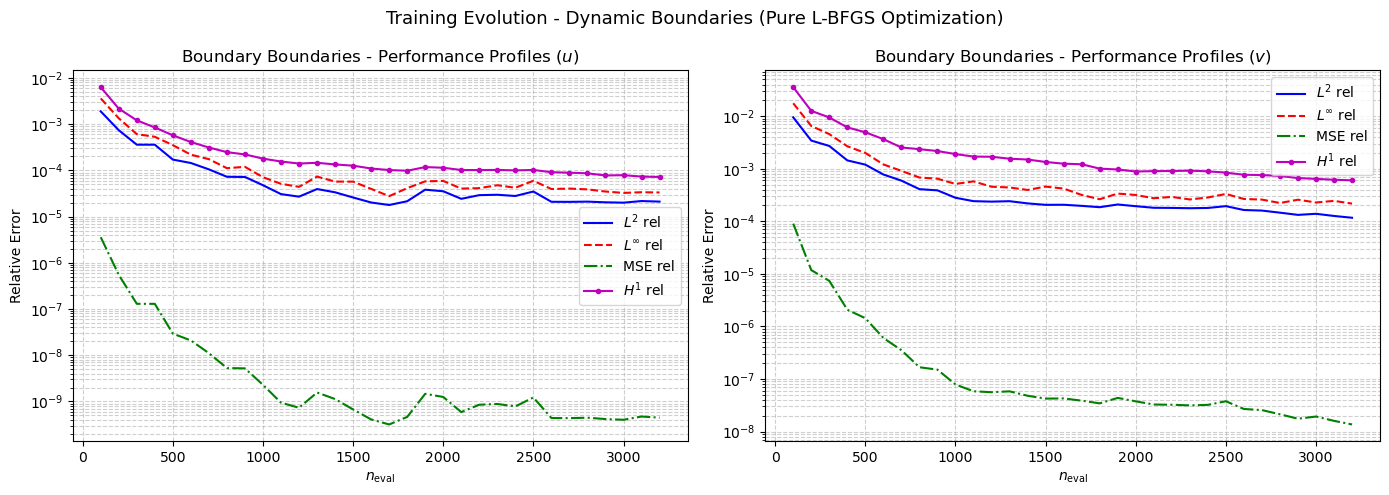

In [13]:
# ==============================================================================
# 🛠️ STEP 3 CORRIGÉ : RUNNER ENGINE AND PLOTTING MODULE (100% PURE L-BFGS ONLY)
# ==============================================================================

# Instantiating a brand-new model instance to optimize with pure L-BFGS
model = NN()

hist = []
epochs = []

hist_L2_u_i, hist_Linf_u_i, hist_MSE_u_i, hist_H1_u_i = [], [], [], []
hist_L2_v_i, hist_Linf_v_i, hist_MSE_v_i, hist_H1_v_i = [], [], [], []

hist_L2_u_b, hist_Linf_u_b, hist_MSE_u_b, hist_H1_u_b = [], [], [], []
hist_L2_v_b, hist_Linf_v_b, hist_MSE_v_b, hist_H1_v_b = [], [], [], []

print("\n--- Initializing Pure L-BFGS Optimization Framework ---")

# FIX: Changed from 0 to [0] to match your factory list-counter logic!
step_counter = [0] 

histories_map = {
    'epochs': epochs,
    'hist_L2_u_i': hist_L2_u_i, 'hist_Linf_u_i': hist_Linf_u_i, 'hist_MSE_u_i': hist_MSE_u_i, 'hist_H1_u_i': hist_H1_u_i,
    'hist_L2_v_i': hist_L2_v_i, 'hist_Linf_v_i': hist_Linf_v_i, 'hist_MSE_v_i': hist_MSE_v_i, 'hist_H1_v_i': hist_H1_v_i,
    'hist_L2_u_b': hist_L2_u_b, 'hist_Linf_u_b': hist_Linf_u_b, 'hist_MSE_u_b': hist_MSE_u_b, 'hist_H1_u_b': hist_H1_u_b,
    'hist_L2_v_b': hist_L2_v_b, 'hist_Linf_v_b': hist_Linf_v_b, 'hist_MSE_v_b': hist_MSE_v_b, 'hist_H1_v_b': hist_H1_v_b
}

# Pack the objective function mapping directly to empty histories
wrapped_loss_grad_fn = lbfgs_factory_pure(model, get_grad, X_i, X_b, step_counter, hist, histories_map)

# Extract original randomly initialized model weight configurations
initial_weights_1d = tf.concat([tf.reshape(v, [-1]) for v in model.trainable_variables], axis=0)

t_start = time()
lbfgs_results = tfp.optimizer.lbfgs_minimize(
    value_and_gradients_function=wrapped_loss_grad_fn, 
    initial_position=initial_weights_1d,
    max_iterations=4000,                  # Ample budget allocations
    num_correction_pairs=50,
    tolerance=1e-16,                      
    f_relative_tolerance=1e-16,           
    x_tolerance=1e-16,                    
    max_line_search_iterations=100        
)

print(f"\nL-BFGS finalized in {time() - t_start:.2f} s. Convergence flag: {lbfgs_results.converged.numpy()}")
print(f"Final minimized objective loss reached: {lbfgs_results.objective_value.numpy():.3e}")

# ============================================================
# PERFORMANCE PLOTS SUITE
# ============================================================

# 1. Total Optimization Loss History
plt.figure(figsize=(7, 5))
plt.semilogy(range(len(hist)), hist, 'k-')
plt.xlabel("$n_{\mathrm{eval}}$")
plt.ylabel("$\mathcal{L}$")
plt.title("")
plt.legend(); plt.grid(True, which='both', alpha=0.5)
plt.tight_layout(); plt.show()

# 2. Interior Point Evaluation Errors
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.semilogy(epochs, hist_L2_u_i,   'b-',   label=r'$L^2$ rel')
plt.semilogy(epochs, hist_Linf_u_i, 'r--',  label=r'$L^\infty$ rel')
plt.semilogy(epochs, hist_MSE_u_i,  'g-.',  label='MSE rel')
plt.semilogy(epochs, hist_H1_u_i,   'm-o',  label=r'$H^1$ rel', markersize=3)
plt.xlabel("$n_{\mathrm{eval}}$")
plt.ylabel('Relative Error')
plt.title('Interior Domain - Performance Profiles ($u$)')
plt.legend(); plt.grid(True, which='both', linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.semilogy(epochs, hist_L2_v_i,   'b-',   label=r'$L^2$ rel')
plt.semilogy(epochs, hist_Linf_v_i, 'r--',  label=r'$L^\infty$ rel')
plt.semilogy(epochs, hist_MSE_v_i,  'g-.',  label='MSE rel')
plt.semilogy(epochs, hist_H1_v_i,   'm-o',  label=r'$H^1$ rel', markersize=3)
plt.xlabel("$n_{\mathrm{eval}}$")
plt.ylabel('Relative Error')
plt.title('Interior Domain - Performance Profiles ($v$)')
plt.legend(); plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.suptitle('Training Evolution - Interior Fields (Pure L-BFGS Optimization)', fontsize=13)
plt.tight_layout(); plt.show()

# 3. Boundary Point Evaluation Errors
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.semilogy(epochs, hist_L2_u_b,   'b-',   label=r'$L^2$ rel')
plt.semilogy(epochs, hist_Linf_u_b, 'r--',  label=r'$L^\infty$ rel')
plt.semilogy(epochs, hist_MSE_u_b,  'g-.',  label='MSE rel')
plt.semilogy(epochs, hist_H1_u_b,   'm-o',  label=r'$H^1$ rel', markersize=3)
plt.xlabel("$n_{\mathrm{eval}}$")
plt.ylabel('Relative Error')
plt.title('Boundary Boundaries - Performance Profiles ($u$)')
plt.legend(); plt.grid(True, which='both', linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.semilogy(epochs, hist_L2_v_b,   'b-',   label=r'$L^2$ rel')
plt.semilogy(epochs, hist_Linf_v_b, 'r--',  label=r'$L^\infty$ rel')
plt.semilogy(epochs, hist_MSE_v_b,  'g-.',  label='MSE rel')
plt.semilogy(epochs, hist_H1_v_b,   'm-o',  label=r'$H^1$ rel', markersize=3)
plt.xlabel("$n_{\mathrm{eval}}$")
plt.ylabel('Relative Error')
plt.title('Boundary Boundaries - Performance Profiles ($v$)')
plt.legend(); plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.suptitle('Training Evolution - Dynamic Boundaries (Pure L-BFGS Optimization)', fontsize=13)
plt.tight_layout(); plt.show()


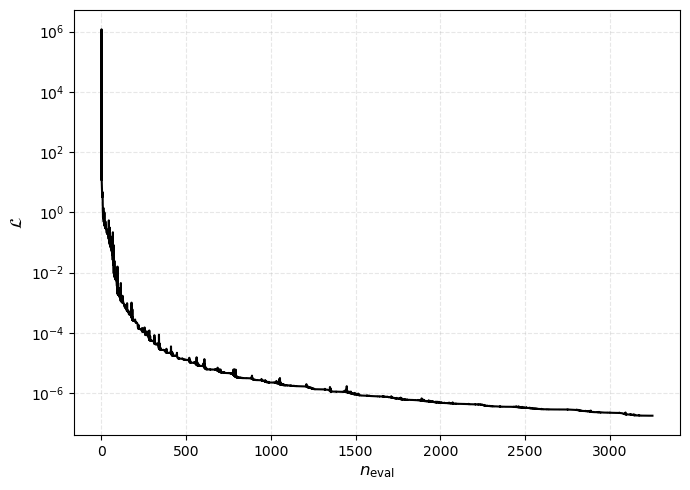

In [14]:
plt.figure(figsize=(7, 5))

# Added label to ensure plt.legend() renders cleanly
plt.semilogy(range(len(hist)), hist, 'k-', label=r'$\mathcal{L}$ History')

# FIX: Changed 'lt' to 'plt'
plt.xlabel(r"$n_{\mathrm{eval}}$", fontsize=12)
plt.ylabel(r"$\mathcal{L}$", fontsize=12)
plt.title("")

# Refined layout configurations matching your standard environment setup
plt.grid(True, which='both', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig("Loss_history_n_eval.pdf", format='pdf', bbox_inches='tight', dpi=300)
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


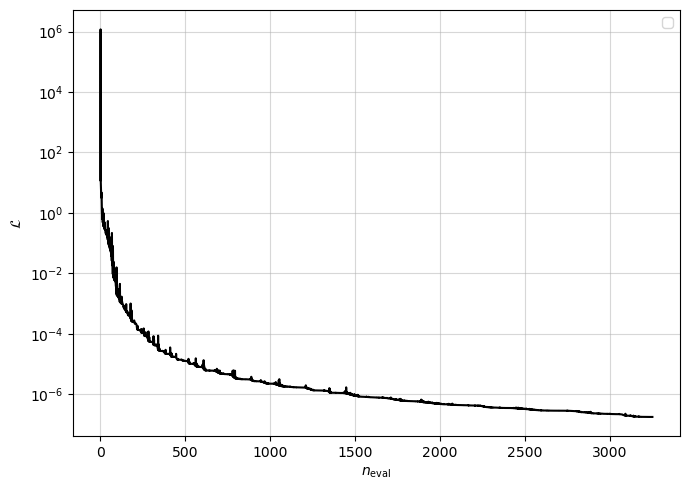

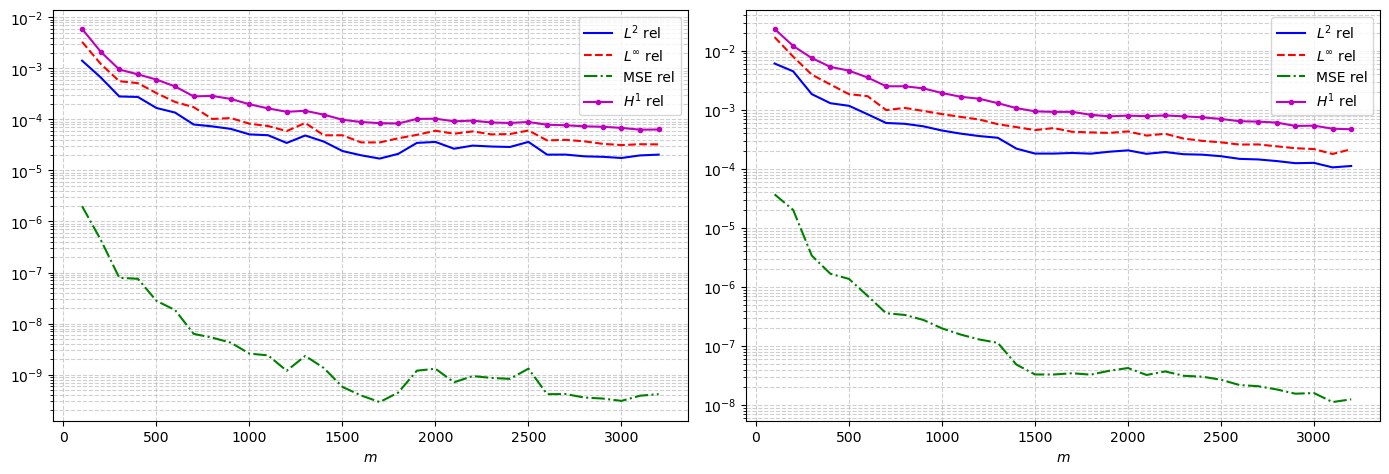

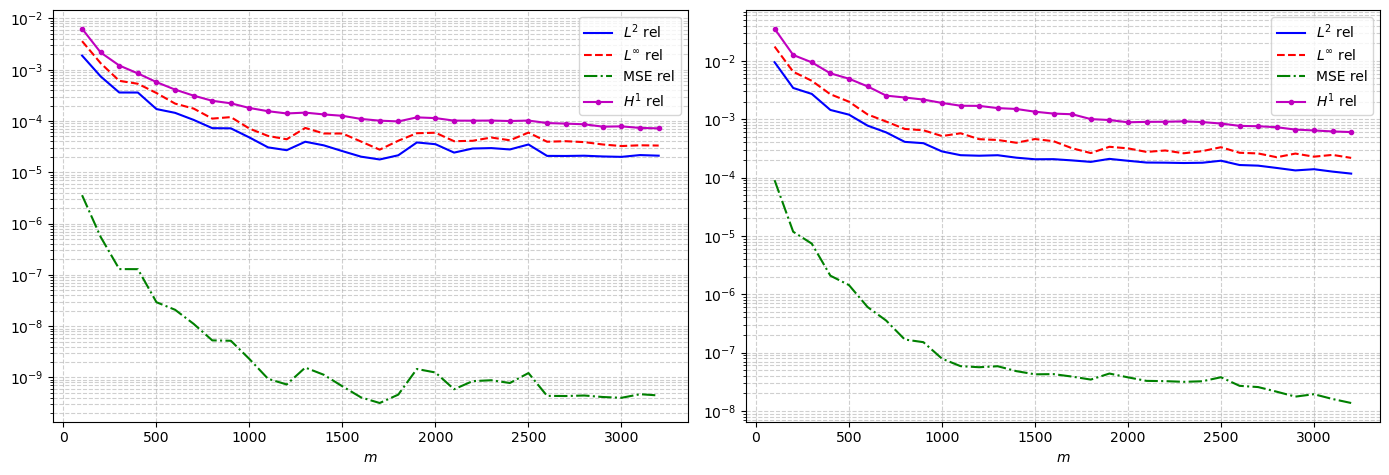

In [15]:
# 1. Total Optimization Loss History
plt.figure(figsize=(7, 5))
plt.semilogy(range(len(hist)), hist, 'k-')
plt.xlabel("$n_{\mathrm{eval}}$")
plt.ylabel("$\mathcal{L}$")
plt.title("")
plt.legend(); plt.grid(True, which='both', alpha=0.5)
plt.tight_layout(); plt.show()

# 2. Interior Point Evaluation Errors
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.semilogy(epochs, hist_L2_u_i,   'b-',   label=r'$L^2$ rel')
plt.semilogy(epochs, hist_Linf_u_i, 'r--',  label=r'$L^\infty$ rel')
plt.semilogy(epochs, hist_MSE_u_i,  'g-.',  label='MSE rel')
plt.semilogy(epochs, hist_H1_u_i,   'm-o',  label=r'$H^1$ rel', markersize=3)
plt.xlabel("$m$")
plt.ylabel('')
plt.title('')
plt.legend(); plt.grid(True, which='both', linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.semilogy(epochs, hist_L2_v_i,   'b-',   label=r'$L^2$ rel')
plt.semilogy(epochs, hist_Linf_v_i, 'r--',  label=r'$L^\infty$ rel')
plt.semilogy(epochs, hist_MSE_v_i,  'g-.',  label='MSE rel')
plt.semilogy(epochs, hist_H1_v_i,   'm-o',  label=r'$H^1$ rel', markersize=3)
plt.xlabel("$m$")
plt.ylabel('')
plt.title('')
plt.legend(); plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.suptitle('', fontsize=13)
plt.tight_layout(); plt.show()

# 3. Boundary Point Evaluation Errors
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.semilogy(epochs, hist_L2_u_b,   'b-',   label=r'$L^2$ rel')
plt.semilogy(epochs, hist_Linf_u_b, 'r--',  label=r'$L^\infty$ rel')
plt.semilogy(epochs, hist_MSE_u_b,  'g-.',  label='MSE rel')
plt.semilogy(epochs, hist_H1_u_b,   'm-o',  label=r'$H^1$ rel', markersize=3)
plt.xlabel("$m$")
plt.ylabel('')
plt.title('')
plt.legend(); plt.grid(True, which='both', linestyle='--', alpha=0.6)

plt.subplot(1, 2, 2)
plt.semilogy(epochs, hist_L2_v_b,   'b-',   label=r'$L^2$ rel')
plt.semilogy(epochs, hist_Linf_v_b, 'r--',  label=r'$L^\infty$ rel')
plt.semilogy(epochs, hist_MSE_v_b,  'g-.',  label='MSE rel')
plt.semilogy(epochs, hist_H1_v_b,   'm-o',  label=r'$H^1$ rel', markersize=3)
plt.xlabel("$m$")
plt.ylabel('')
plt.title('')
plt.legend(); plt.grid(True, which='both', linestyle='--', alpha=0.6)
plt.suptitle('', fontsize=13)
plt.tight_layout(); plt.show()


In [16]:
print("Converged:", lbfgs_results.converged.numpy())
print("Failed:", lbfgs_results.failed.numpy())
print("L-BFGS iterations:",
      lbfgs_results.num_iterations.numpy())
print("Objective evaluations:",
      lbfgs_results.num_objective_evaluations.numpy())

Converged: False
Failed: True
L-BFGS iterations: 1089
Objective evaluations: 3253


In [17]:
loss, rint, rsb, rtb = comp_loss(model)

print(f"Rint      : {rint.numpy():.6e}")
print(f"Rsb             : {rsb.numpy():.6e}")          
print(f"Rtb             : {rtb.numpy():.6e}")
print(f"Total loss        : {loss.numpy():.6e}")

Rint      : 7.205528e-08
Rsb             : 5.656628e-08
Rtb             : 1.155713e-08
Total loss        : 1.760864e-07


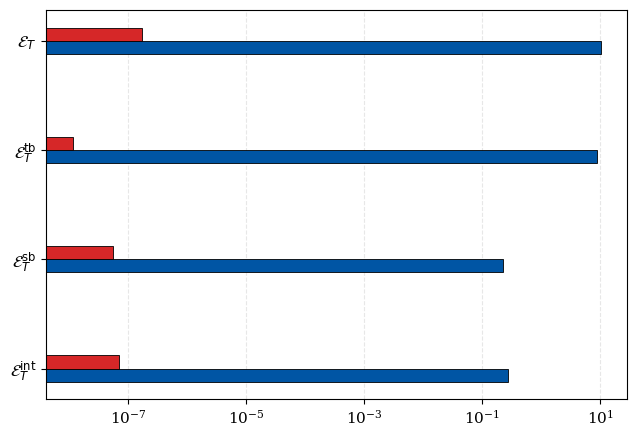

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Configuration des paramètres de style académique Q1
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 12,
})

labels = [
    r'$\mathcal{E}_T^{\mathrm{int}}$',
    r'$\mathcal{E}_T^{\mathrm{sb}}$',
    r'$\mathcal{E}_T^{\mathrm{tb}}$',
    r'$\mathcal{E}_T$'
]

before = np.array([2.761779e-01, 2.271738e-01, 8.729203e+00, 1.015340e+01])
after = np.array([7.205528e-08, 5.656628e-08, 1.155713e-08, 1.760864e-07])

y = np.arange(len(labels))
height = 0.12  

# FIX: Taille harmonisée à (6.5, 4.5) pour le placement côte à côte
fig, ax = plt.subplots(figsize=(6.5, 4.5))  

ax.barh(
    y - height/2,
    before,
    height=height,
    color='#0055A4',
    edgecolor='black',
    linewidth=0.6,
    label='Before training'
)

ax.barh(
    y + height/2,
    after,
    height=height,
    color='#D62728',
    edgecolor='black',
    linewidth=0.6,
    label='After training'
)

ax.set_xscale('log')
ax.set_yticks(y)
ax.set_yticklabels(labels)
ax.set_xlabel('', fontsize=13)
ax.set_title('', fontsize=13, pad=12)

ax.grid(True, which='both', axis='x', linestyle='--', alpha=0.3)
ax.set_axisbelow(True)

# FIX: Réactivation de la légende pour l'affichage correct des labels

plt.tight_layout()
plt.savefig("Kinetic_loss_histogram_horizontal.pdf", format='pdf', bbox_inches='tight', dpi=300)
plt.show()



Computing errors and plotting for t = 0.0
  [Erreurs Relatives - INTÉRIEUR Ω à t=0.0]
    u -> L2 rel: 9.5688e-06 | H1 rel: 9.1246e-05 | Linf rel: 2.1206e-05
    v -> L2 rel: 7.6330e-05 | H1 rel: 4.6306e-04 | Linf rel: 1.3697e-04
  [Erreurs Relatives - BORD Γ à t=0.0]
    u -> L2 rel: 1.2906e-05 | H1 rel: 1.0195e-04 | Linf rel: 2.1183e-05
    v -> L2 rel: 7.6567e-05 | H1 rel: 4.7758e-04 | Linf rel: 1.1873e-04


C:\Users\Dellpc\AppData\Local\Temp\ipykernel_8720\3114371141.py:111: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(


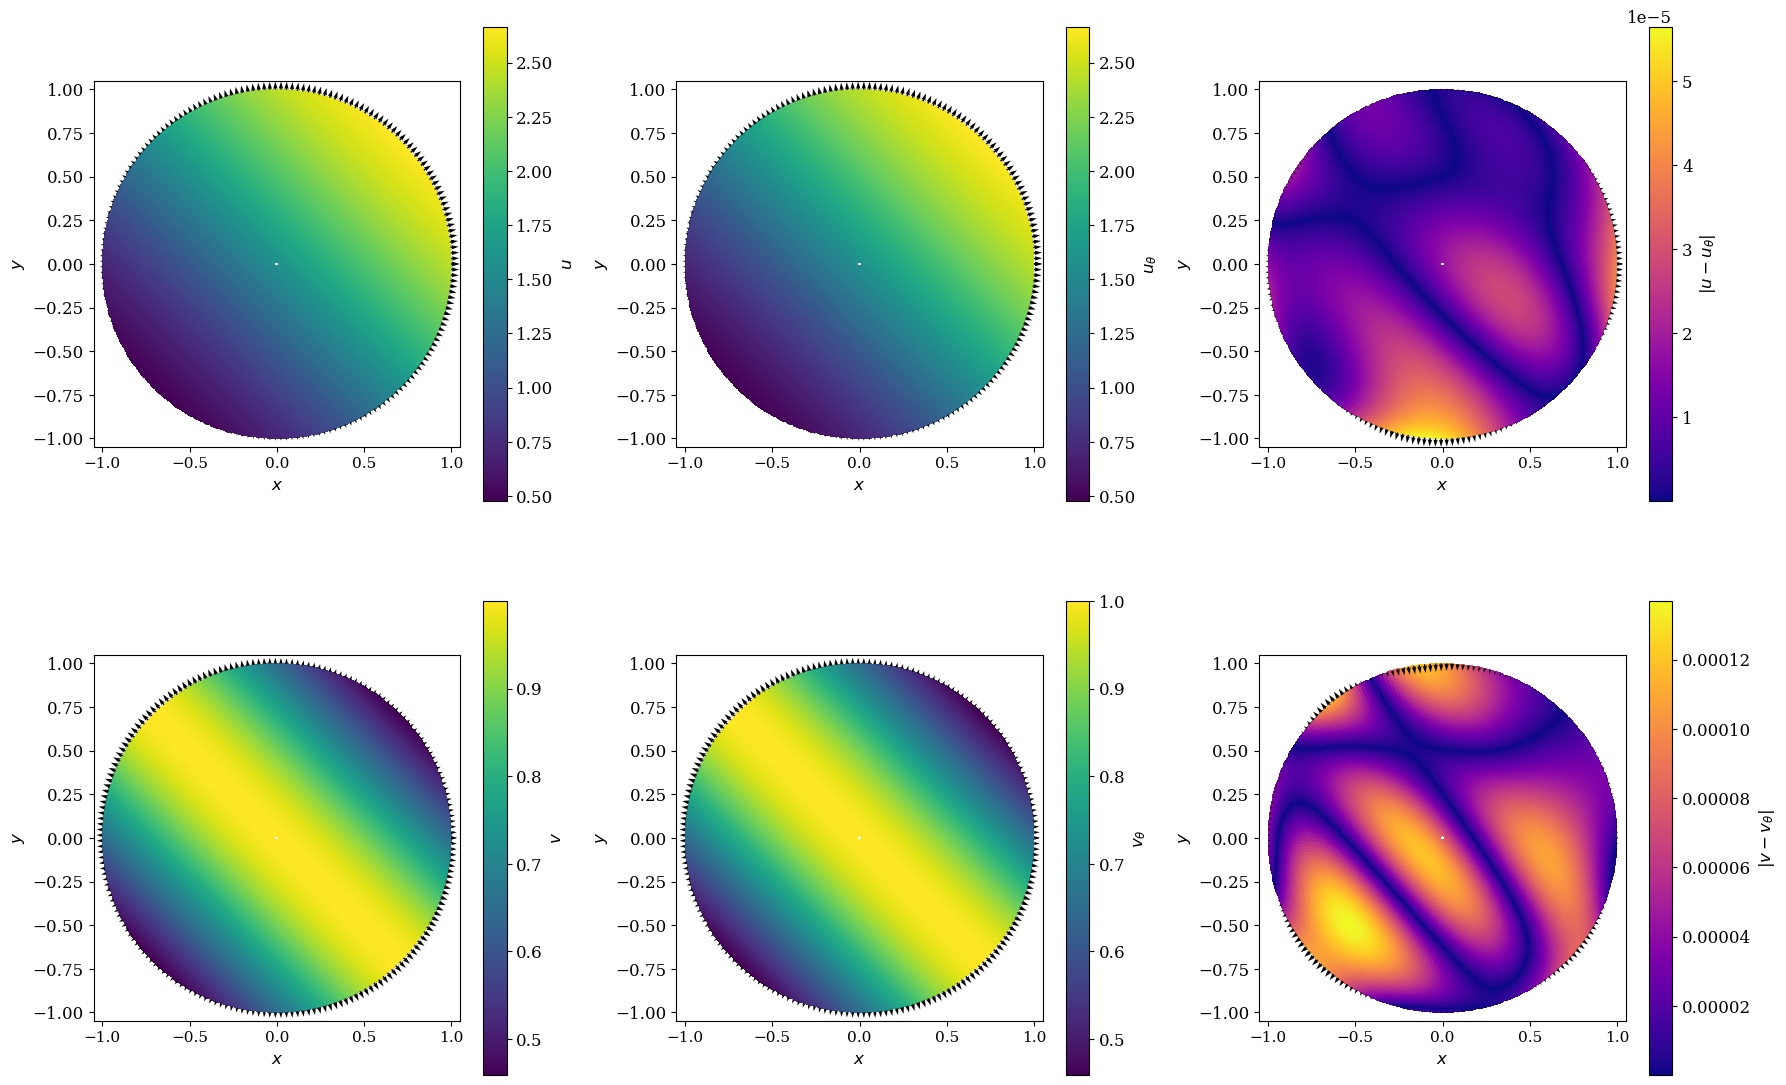


Computing errors and plotting for t = 0.25
  [Erreurs Relatives - INTÉRIEUR Ω à t=0.25]
    u -> L2 rel: 1.3998e-05 | H1 rel: 5.2354e-05 | Linf rel: 2.7720e-05
    v -> L2 rel: 7.8794e-05 | H1 rel: 4.8972e-04 | Linf rel: 1.5748e-04
  [Erreurs Relatives - BORD Γ à t=0.25]
    u -> L2 rel: 1.8218e-05 | H1 rel: 6.0706e-05 | Linf rel: 2.7785e-05
    v -> L2 rel: 8.2397e-05 | H1 rel: 4.2784e-04 | Linf rel: 1.2649e-04


C:\Users\Dellpc\AppData\Local\Temp\ipykernel_8720\3114371141.py:111: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(


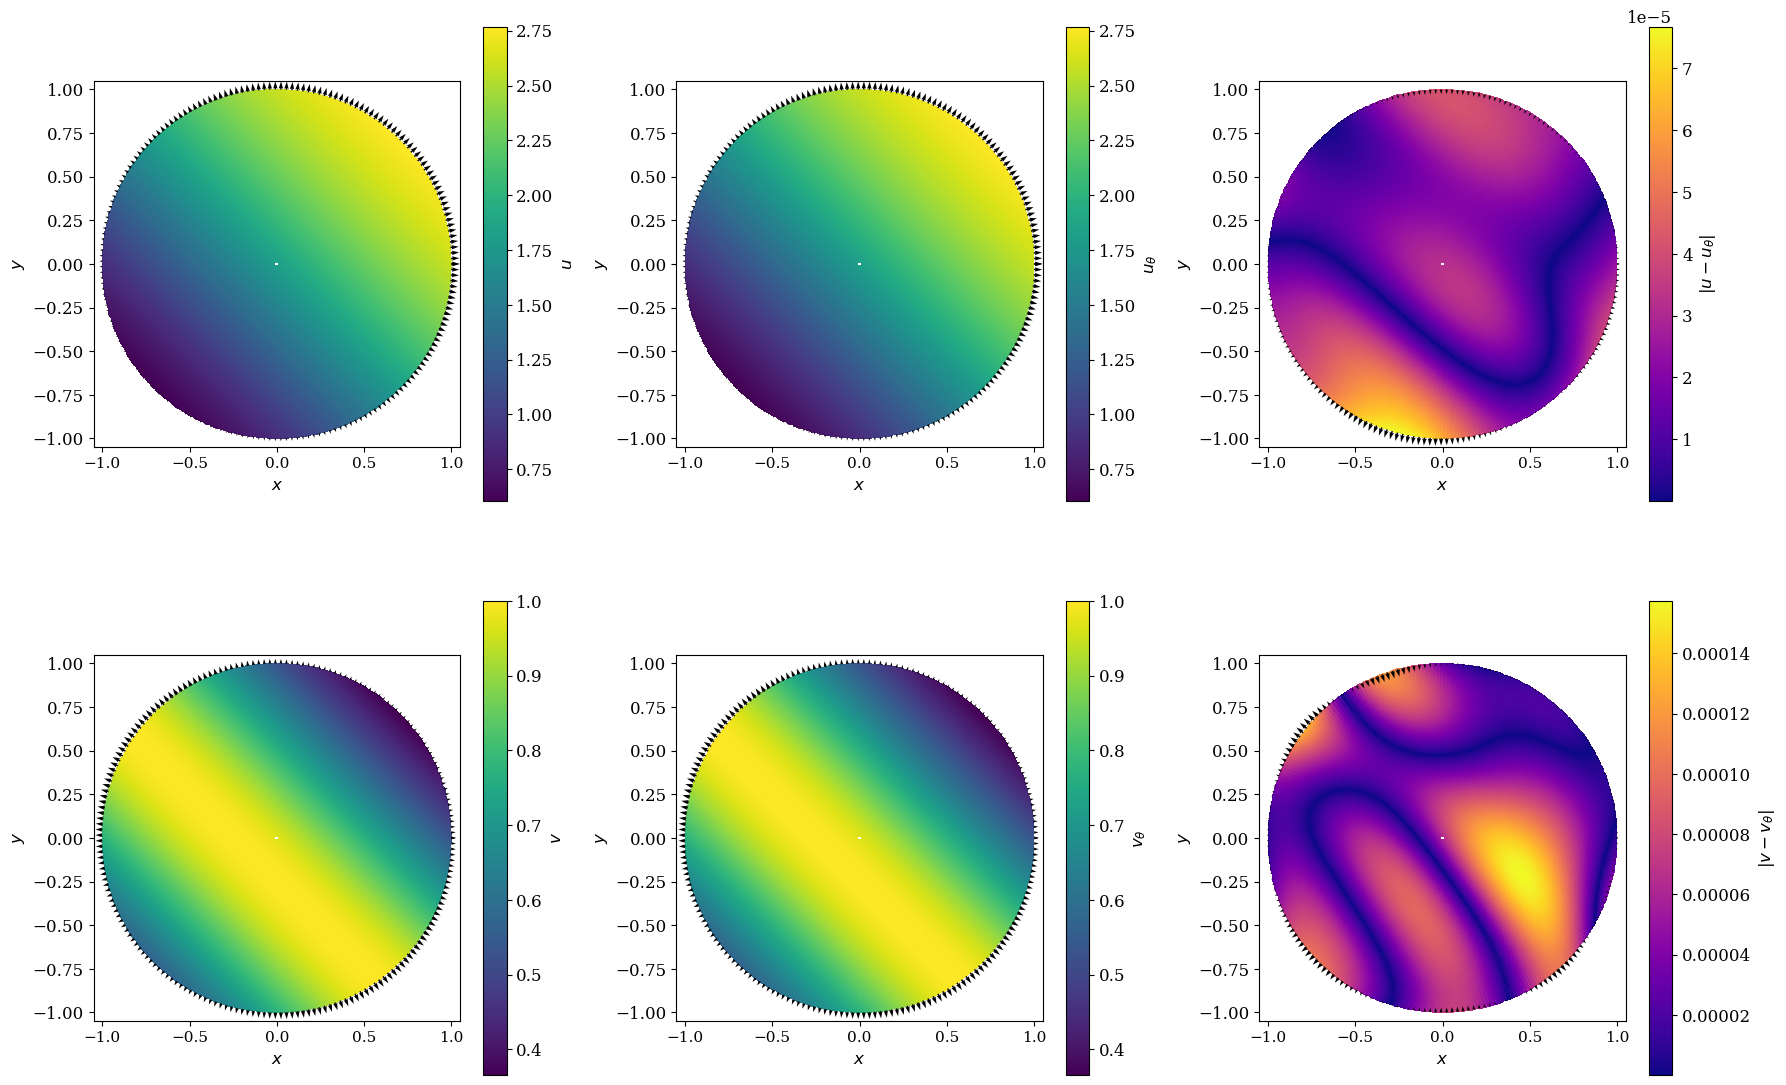


Computing errors and plotting for t = 0.5
  [Erreurs Relatives - INTÉRIEUR Ω à t=0.5]
    u -> L2 rel: 1.4759e-05 | H1 rel: 8.0491e-05 | Linf rel: 3.1322e-05
    v -> L2 rel: 1.3830e-04 | H1 rel: 4.5783e-04 | Linf rel: 2.2447e-04
  [Erreurs Relatives - BORD Γ à t=0.5]
    u -> L2 rel: 2.3991e-05 | H1 rel: 6.4537e-05 | Linf rel: 3.1301e-05
    v -> L2 rel: 9.9326e-05 | H1 rel: 5.5733e-04 | Linf rel: 1.6612e-04


C:\Users\Dellpc\AppData\Local\Temp\ipykernel_8720\3114371141.py:111: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(


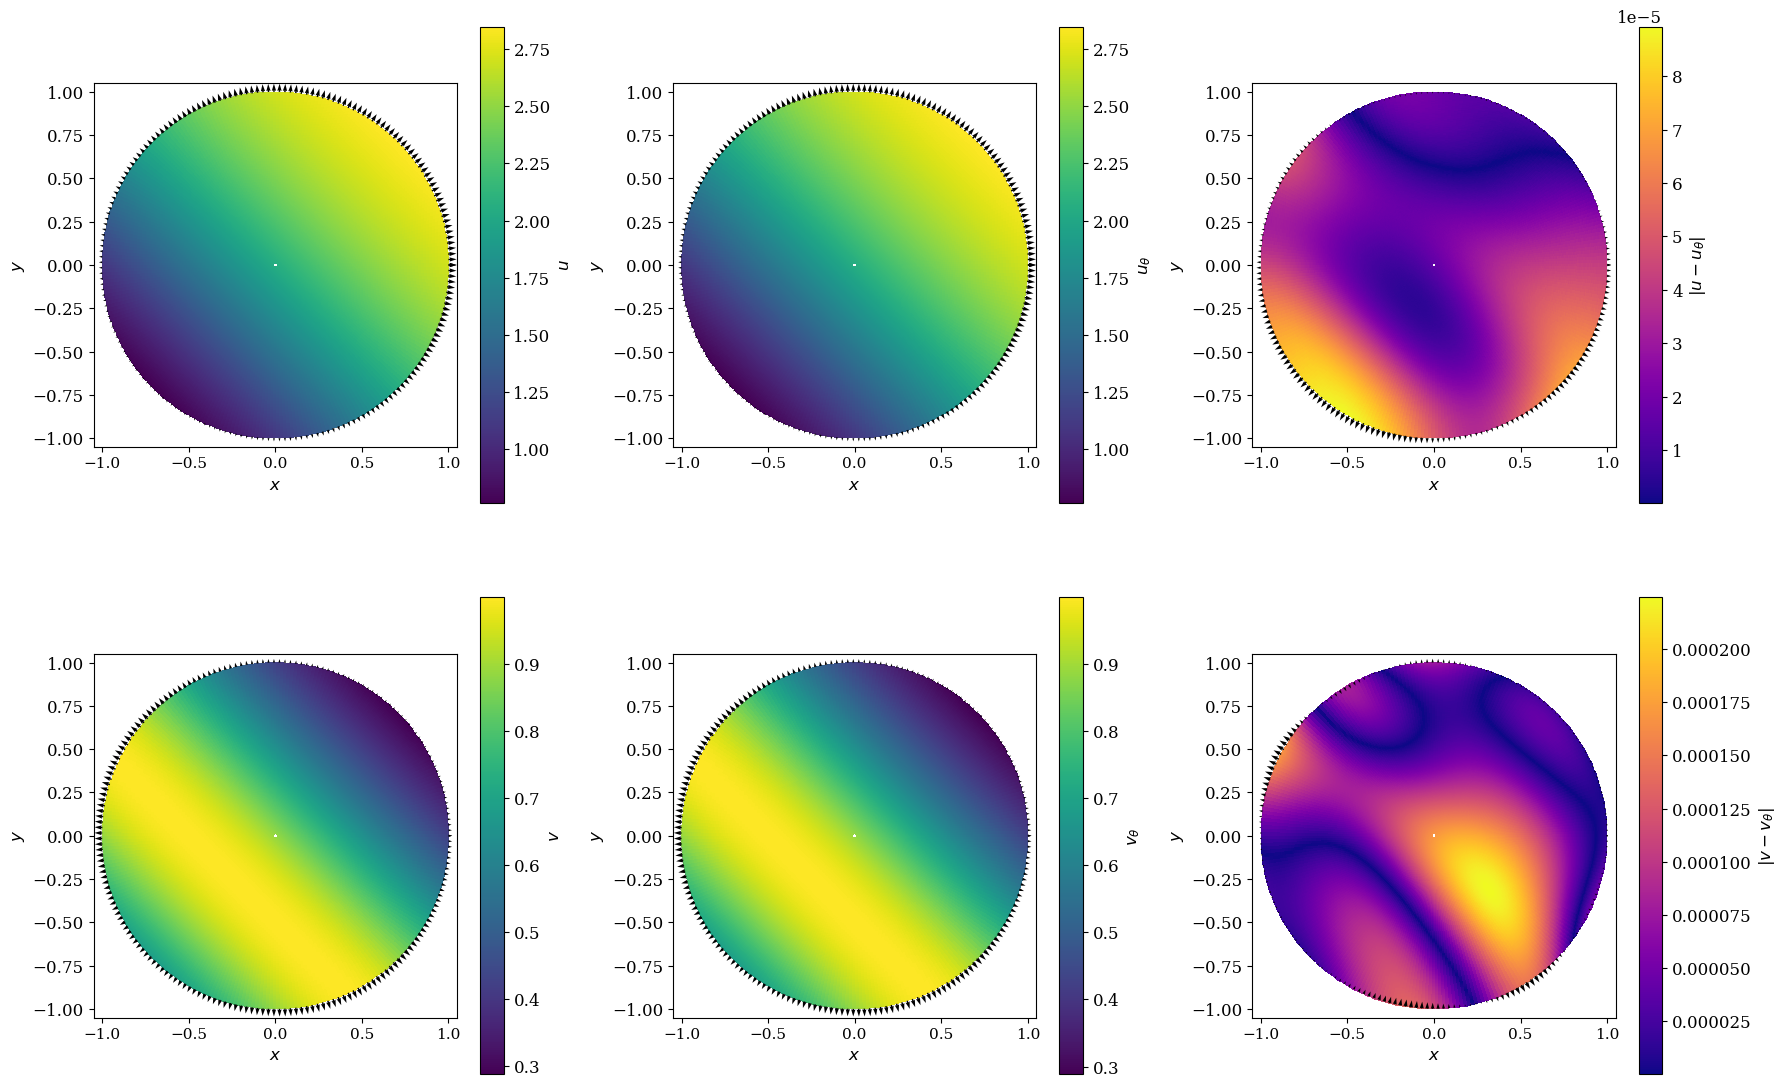


Computing errors and plotting for t = 0.75
  [Erreurs Relatives - INTÉRIEUR Ω à t=0.75]
    u -> L2 rel: 2.8305e-05 | H1 rel: 6.3370e-05 | Linf rel: 3.3313e-05
    v -> L2 rel: 1.7014e-04 | H1 rel: 4.5743e-04 | Linf rel: 2.4468e-04
  [Erreurs Relatives - BORD Γ à t=0.75]
    u -> L2 rel: 2.5565e-05 | H1 rel: 6.3809e-05 | Linf rel: 3.3394e-05
    v -> L2 rel: 1.4190e-04 | H1 rel: 6.9728e-04 | Linf rel: 1.9069e-04


C:\Users\Dellpc\AppData\Local\Temp\ipykernel_8720\3114371141.py:111: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(


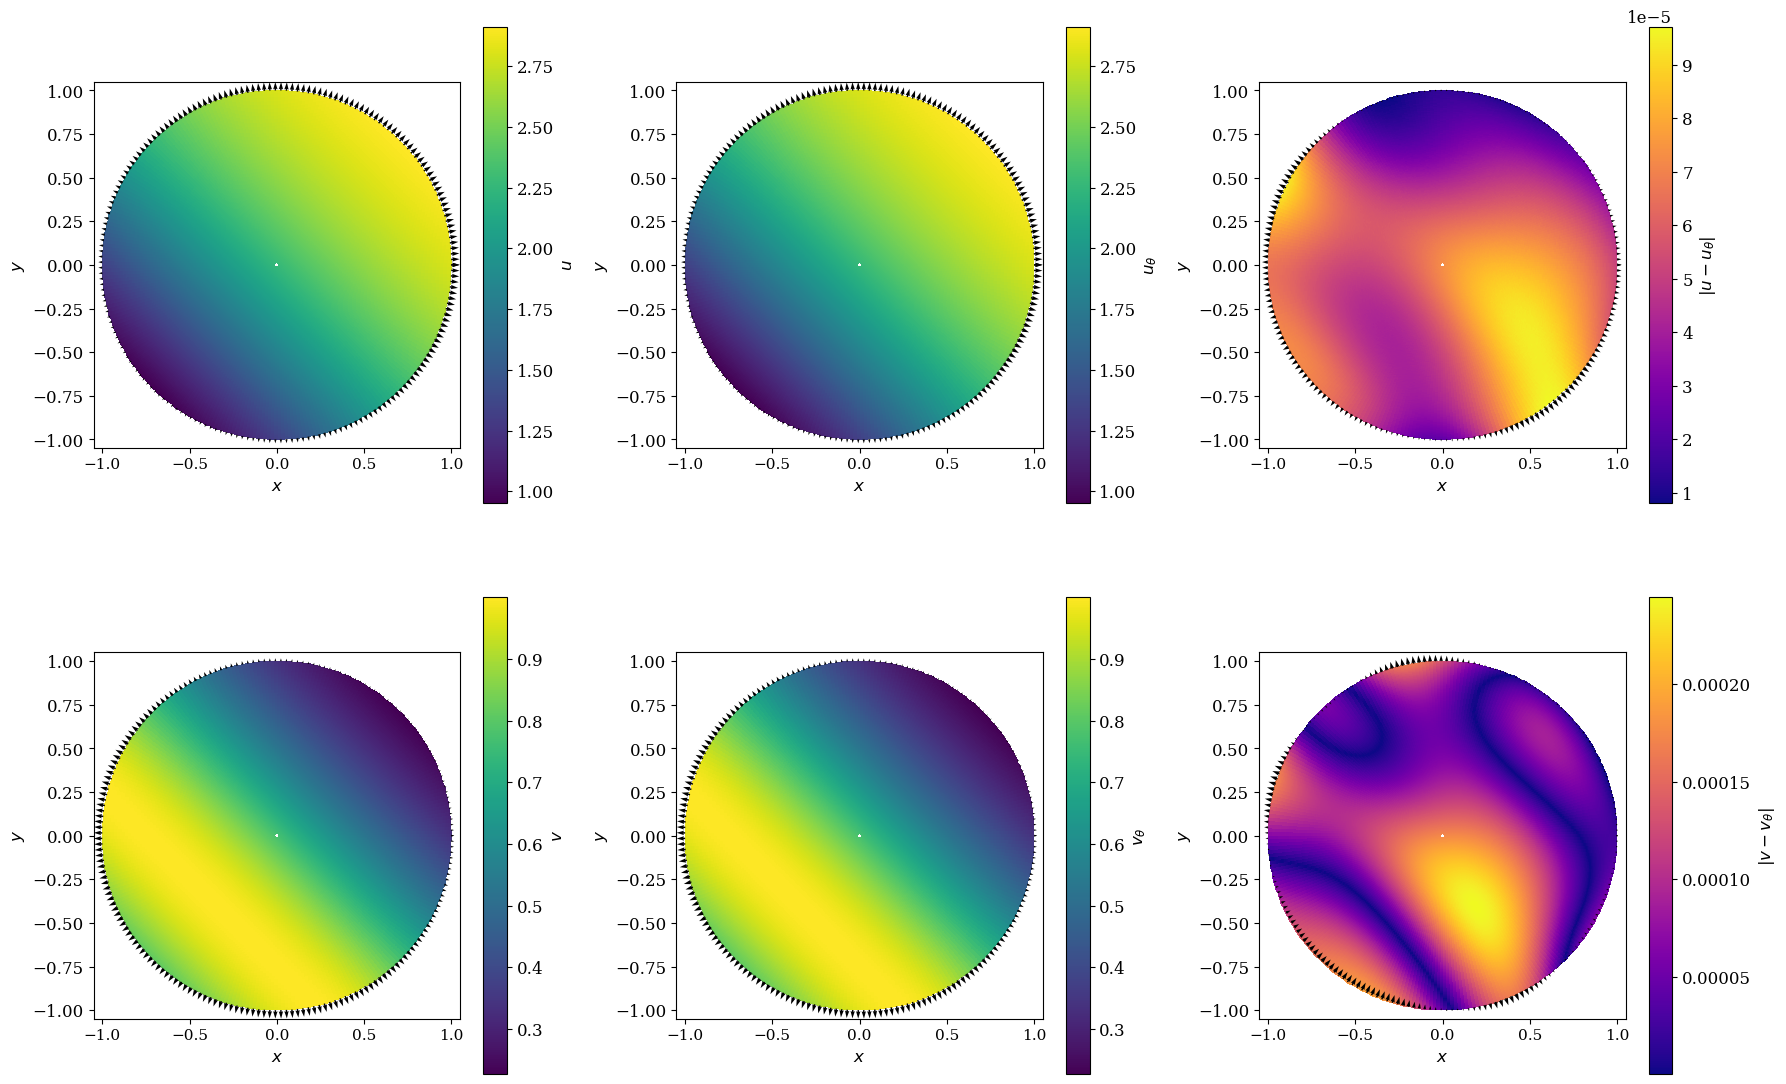


Computing errors and plotting for t = 1.0
  [Erreurs Relatives - INTÉRIEUR Ω à t=1.0]
    u -> L2 rel: 2.8264e-05 | H1 rel: 7.4916e-05 | Linf rel: 3.6127e-05
    v -> L2 rel: 1.2132e-04 | H1 rel: 6.4768e-04 | Linf rel: 2.3797e-04
  [Erreurs Relatives - BORD Γ à t=1.0]
    u -> L2 rel: 1.6585e-05 | H1 rel: 1.1897e-04 | Linf rel: 3.2023e-05
    v -> L2 rel: 1.6136e-04 | H1 rel: 1.0317e-03 | Linf rel: 2.3804e-04


C:\Users\Dellpc\AppData\Local\Temp\ipykernel_8720\3114371141.py:111: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(


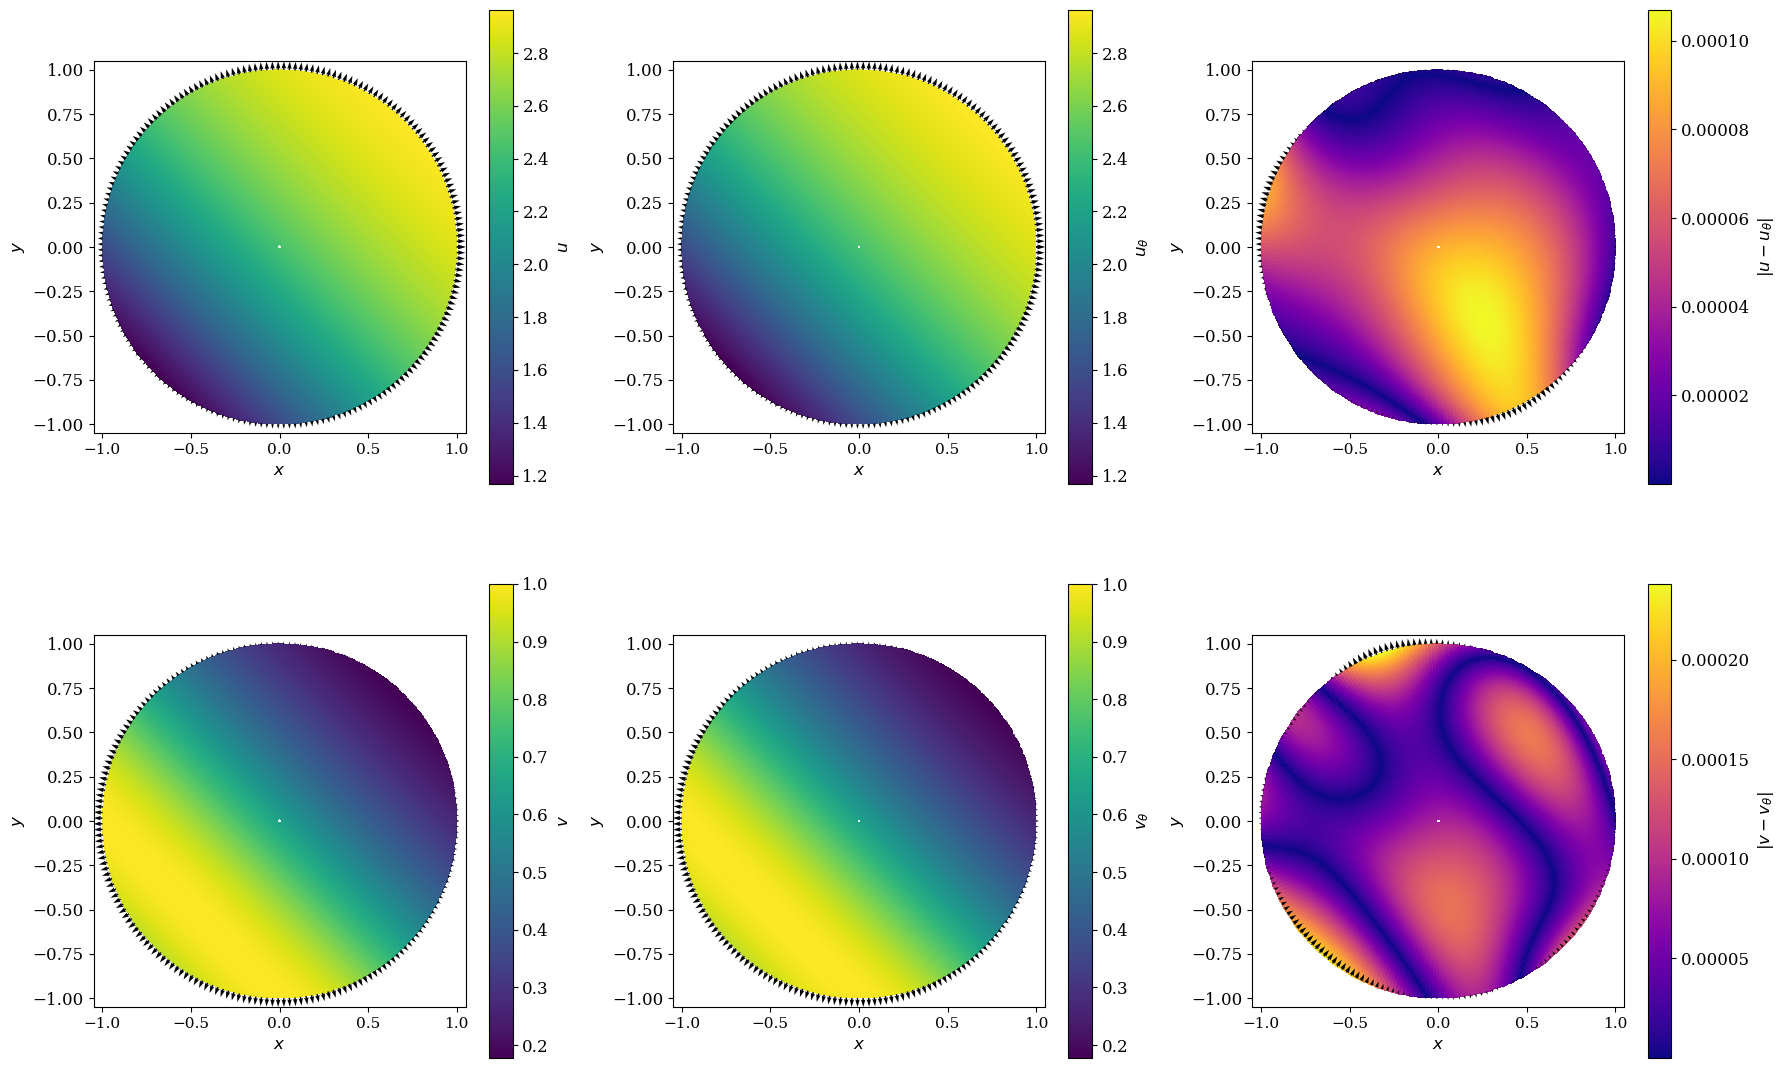

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


# =============================
# Paramètres généraux
# =============================
DTYPE = tf.float32
N_int = 300
N_b = 200

t_values = [0.0, 0.25, 0.50, 0.75, 1.00]

# =============================
# Domaine intérieur (fixe)
# =============================
r_vals = np.linspace(0.01, 1.0, N_int)
theta_vals = np.linspace(0, 2*np.pi, N_int)

r, theta = np.meshgrid(r_vals, theta_vals)

x_int = r * np.cos(theta)
y_int = r * np.sin(theta)

# =============================
# Domaine du bord (fixe)
# =============================
theta_b = np.linspace(0, 2*np.pi, N_b)

x_b = np.cos(theta_b)
y_b = np.sin(theta_b)

# =============================
# Boucle sur les instants t
# =============================
for t_fix in t_values:

    print(f"\n==================================================")
    print(f"Computing errors and plotting for t = {t_fix}")
    print(f"==================================================")

    # =============================
    # Interior points preparation
    # =============================
    t_int = np.full_like(x_int, t_fix)
    X_int = np.stack([x_int.flatten(), y_int.flatten(), t_int.flatten()], axis=1)
    X_int_tf = tf.convert_to_tensor(X_int, dtype=DTYPE)

    # =============================
    # Boundary points preparation
    # =============================
    t_b_arr = np.full_like(x_b, t_fix)
    X_b = np.stack([x_b, y_b, t_b_arr], axis=1)
    X_b_tf = tf.convert_to_tensor(X_b, dtype=DTYPE)

    # =========================================================
    # CALCUL DES ERREURS RELATIVES VIA VOTRE FONCTION MAÎTRESSE
    # =========================================================
    L2_u_i, Linf_u_i, MSE_u_i, L2_v_i, Linf_v_i, MSE_v_i, H1_u_i, H1_v_i = \
        compute_errors_on_points(model, X_int_tf)
        
    L2_u_b, Linf_u_b, MSE_u_b, L2_v_b, Linf_v_b, MSE_v_b, H1_u_b, H1_v_b = \
        compute_errors_on_points(model, X_b_tf)

    # Affichage des erreurs relatives sous forme de tableau académique
    print(f"  [Erreurs Relatives - INTÉRIEUR Ω à t={t_fix}]")
    print(f"    u -> L2 rel: {L2_u_i:.4e} | H1 rel: {H1_u_i:.4e} | Linf rel: {Linf_u_i:.4e}")
    print(f"    v -> L2 rel: {L2_v_i:.4e} | H1 rel: {H1_v_i:.4e} | Linf rel: {Linf_v_i:.4e}")
    print(f"  [Erreurs Relatives - BORD Γ à t={t_fix}]")
    print(f"    u -> L2 rel: {L2_u_b:.4e} | H1 rel: {H1_u_b:.4e} | Linf rel: {Linf_u_b:.4e}")
    print(f"    v -> L2 rel: {L2_v_b:.4e} | H1 rel: {H1_v_b:.4e} | Linf rel: {Linf_v_b:.4e}")

    # =========================================================
    # ÉVALUATIONS DIRECTES DES DEUX SORTIES DU RÉSEAU (u et v)
    # =========================================================
    uv_pred_int = model(X_int_tf).numpy()
    uv_pred_b   = model(X_b_tf).numpy()

    # Extraction directe des composantes sans differentiation automatique
    u_pred_int = uv_pred_int[:, 0].reshape(N_int, N_int)
    v_pred_int = uv_pred_int[:, 1].reshape(N_int, N_int) # Directement la 2ème sortie !

    u_pred_b   = uv_pred_b[:, 0].flatten()
    v_pred_b   = uv_pred_b[:, 1].flatten() # Directement la 2ème sortie !

    # =========================================================
    # SOLUTIONS EXACTES ANALYTIQUES : 2*arctan(exp(x+y+t))
    # =========================================================
    # Intérieur
    exp_int = np.exp(x_int + y_int + t_fix)
    u_exact_int = 2.0 * np.arctan(exp_int)
    v_exact_int = 2.0 * exp_int / (1.0 + exp_int**2) # v_exact = ∂t(u_exact)

    # Bord
    exp_b = np.exp(x_b + y_b + t_fix)
    u_exact_b = 2.0 * np.arctan(exp_b)
    v_exact_b = 2.0 * exp_b / (1.0 + exp_b**2)

    # Profils d'erreurs absolues pour les cartes spatiales d'écarts
    u_err_int = u_exact_int - u_pred_int
    u_err_b   = u_exact_b   - u_pred_b

    v_err_int = v_exact_int - v_pred_int
    v_err_b   = v_exact_b   - v_pred_b

    # =========================================================
    # Fonction de tracé générique (Style d'origine conservé)
    # =========================================================
    def plot_field(ax, field_int, field_b, cmap, label):
        im = ax.pcolormesh(
            x_int, y_int, field_int,
            shading='auto', cmap=cmap
        )
        scale_factor = 0.05 / (np.max(np.abs(field_b)) + 1e-10)
        dx = scale_factor * field_b * x_b
        dy = scale_factor * field_b * y_b
        ax.quiver(
            x_b, y_b, dx, dy,
            color='black', angles='xy',
            scale_units='xy', scale=1, width=0.004
        )
        ax.set_aspect('equal')
        ax.set_xlim(-1.05, 1.05)
        ax.set_ylim(-1.05, 1.05)
        ax.set_xlabel('$x$')
        ax.set_ylabel('$y$')
        fig.colorbar(im, ax=ax, shrink=0.8, label=label)

    # Initialisation de la figure (2 lignes, 3 colonnes)
    fig, axs = plt.subplots(2, 3, figsize=(18, 12))

    # ---------------------------------------------------------
    # LIGNE 1 : Tracés pour la fonction u
    # ---------------------------------------------------------
    # u — Exacte
    plot_field(axs[0, 0], u_exact_int, u_exact_b, 'viridis', r'$u$')

    # u — Approchée (PINN)
    plot_field(axs[0, 1], u_pred_int, u_pred_b, 'viridis', r'$u_\theta$')

    # u — Écart Absolu
    plot_field(axs[0, 2], np.abs(u_err_int), u_err_b, 'plasma', r'$|u-u_\theta|$')

    # ---------------------------------------------------------
    # LIGNE 2 : Tracés pour le champ v (Prédit par la 2ème sortie)
    # ---------------------------------------------------------
    # v — Exacte
    plot_field(axs[1, 0], v_exact_int, v_exact_b, 'viridis', r'$v$')

    # v — Approchée (PINN direct output)
    plot_field(axs[1, 1], v_pred_int, v_pred_b, 'viridis', r'$v_\theta$')

    # v — Écart Absolu
    plot_field(axs[1, 2], np.abs(v_err_int), v_err_b, 'plasma', r'$|v-v_\theta|$')

    plt.tight_layout()
    
    # Génère un export PDF vectoriel pour votre article
    plt.savefig(f"solution_snapshots_t_{t_fix:.2f}.pdf", format='pdf', bbox_inches='tight')
    plt.show()


Computing errors and plotting for t = 0.0
  [Erreurs Relatives - INTÉRIEUR Ω à t=0.0]
    u -> L2 rel: 9.5688e-06 | H1 rel: 9.1246e-05 | Linf rel: 2.1206e-05
    v -> L2 rel: 7.6330e-05 | H1 rel: 4.6306e-04 | Linf rel: 1.3697e-04
  [Erreurs Relatives - BORD Γ à t=0.0]
    u -> L2 rel: 1.2888e-05 | H1 rel: 1.0200e-04 | Linf rel: 2.1228e-05
    v -> L2 rel: 7.6636e-05 | H1 rel: 4.7785e-04 | Linf rel: 1.1855e-04


C:\Users\Dellpc\AppData\Local\Temp\ipykernel_8720\1686394122.py:111: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(


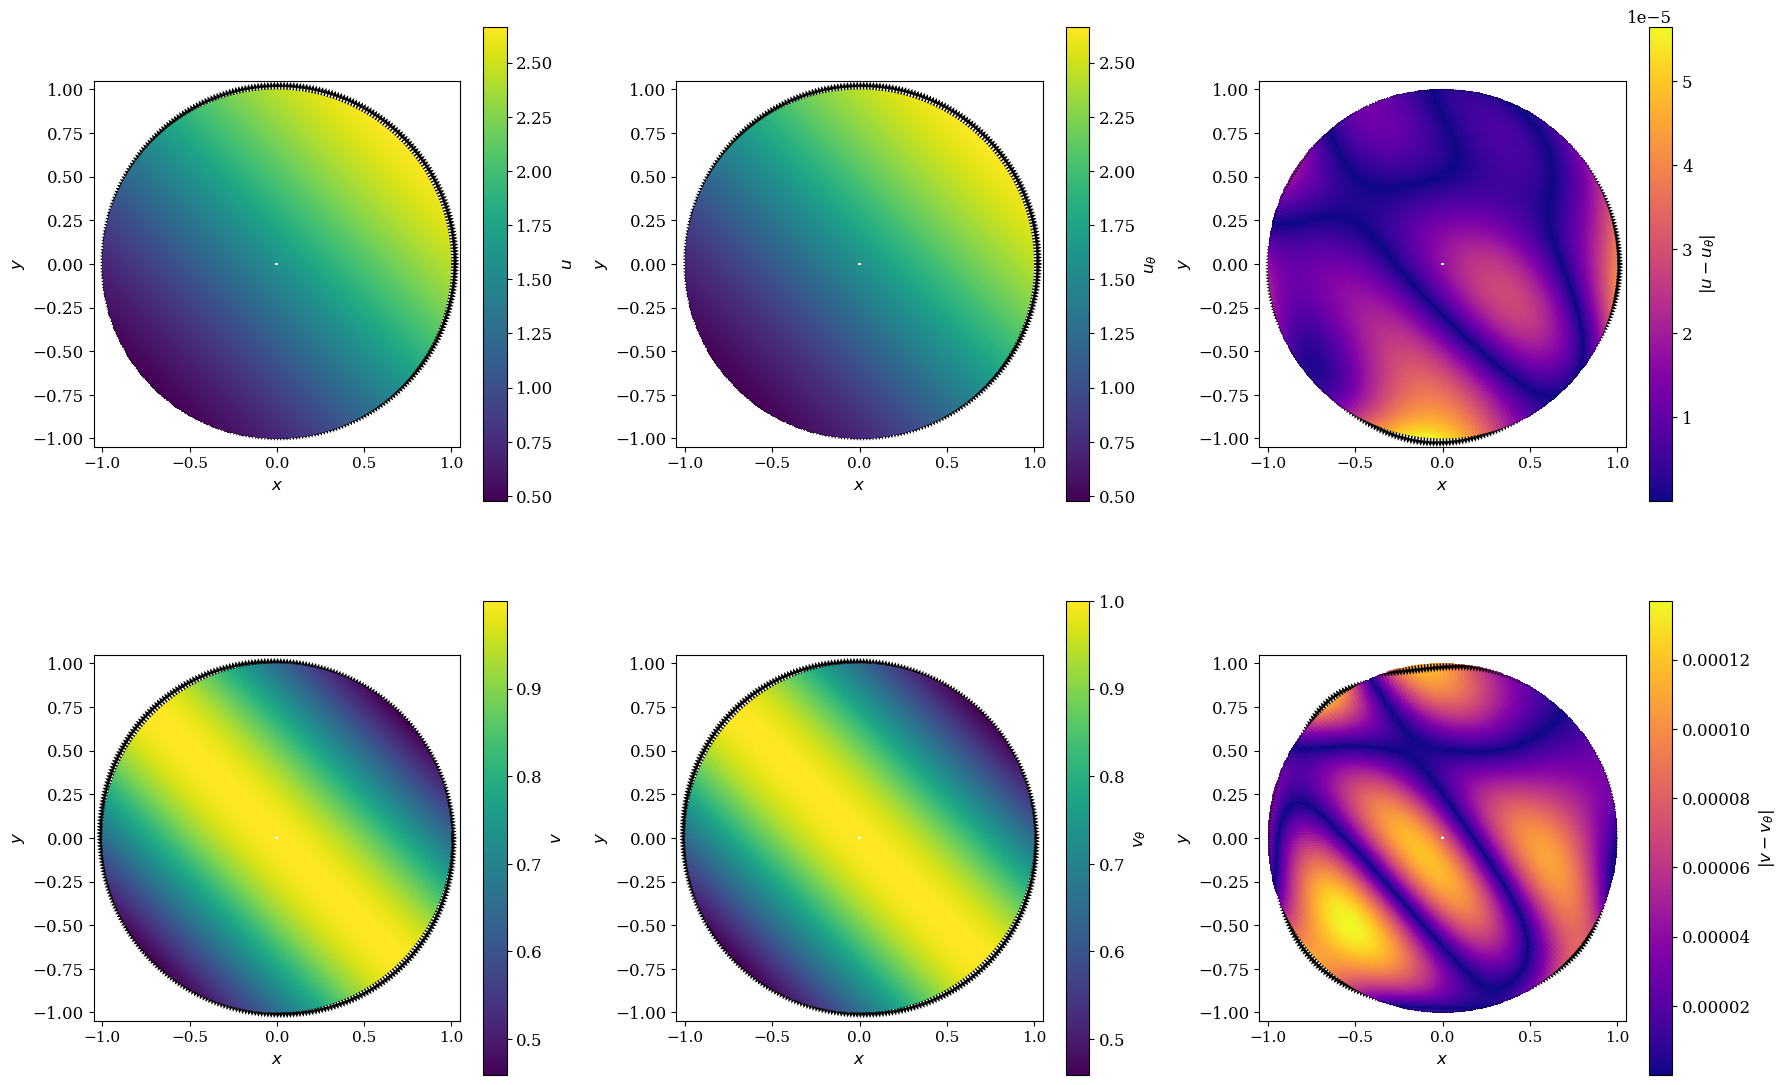


Computing errors and plotting for t = 0.25
  [Erreurs Relatives - INTÉRIEUR Ω à t=0.25]
    u -> L2 rel: 1.3998e-05 | H1 rel: 5.2354e-05 | Linf rel: 2.7720e-05
    v -> L2 rel: 7.8794e-05 | H1 rel: 4.8972e-04 | Linf rel: 1.5748e-04
  [Erreurs Relatives - BORD Γ à t=0.25]
    u -> L2 rel: 1.8250e-05 | H1 rel: 6.0760e-05 | Linf rel: 2.7763e-05
    v -> L2 rel: 8.2431e-05 | H1 rel: 4.2798e-04 | Linf rel: 1.2601e-04


C:\Users\Dellpc\AppData\Local\Temp\ipykernel_8720\1686394122.py:111: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(


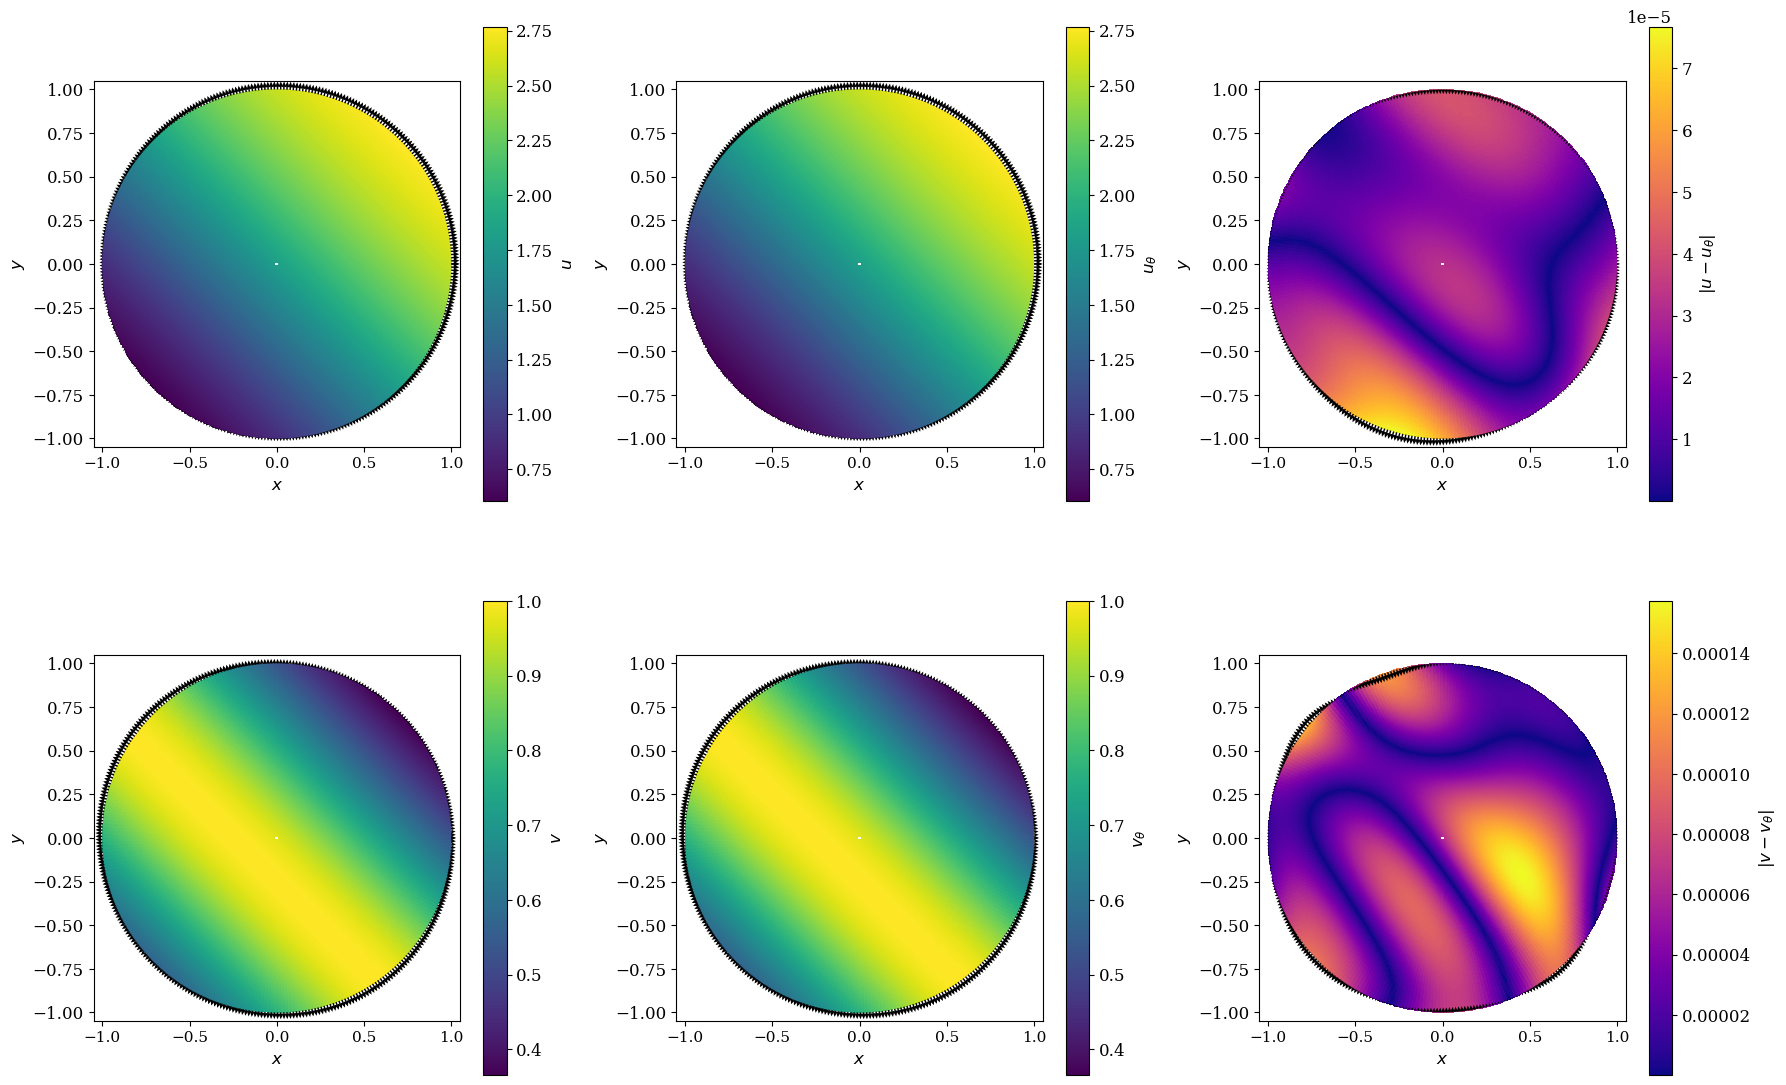


Computing errors and plotting for t = 0.5
  [Erreurs Relatives - INTÉRIEUR Ω à t=0.5]
    u -> L2 rel: 1.4759e-05 | H1 rel: 8.0491e-05 | Linf rel: 3.1322e-05
    v -> L2 rel: 1.3830e-04 | H1 rel: 4.5783e-04 | Linf rel: 2.2447e-04
  [Erreurs Relatives - BORD Γ à t=0.5]
    u -> L2 rel: 2.4028e-05 | H1 rel: 6.4604e-05 | Linf rel: 3.1301e-05
    v -> L2 rel: 9.9319e-05 | H1 rel: 5.5763e-04 | Linf rel: 1.6600e-04


C:\Users\Dellpc\AppData\Local\Temp\ipykernel_8720\1686394122.py:111: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(


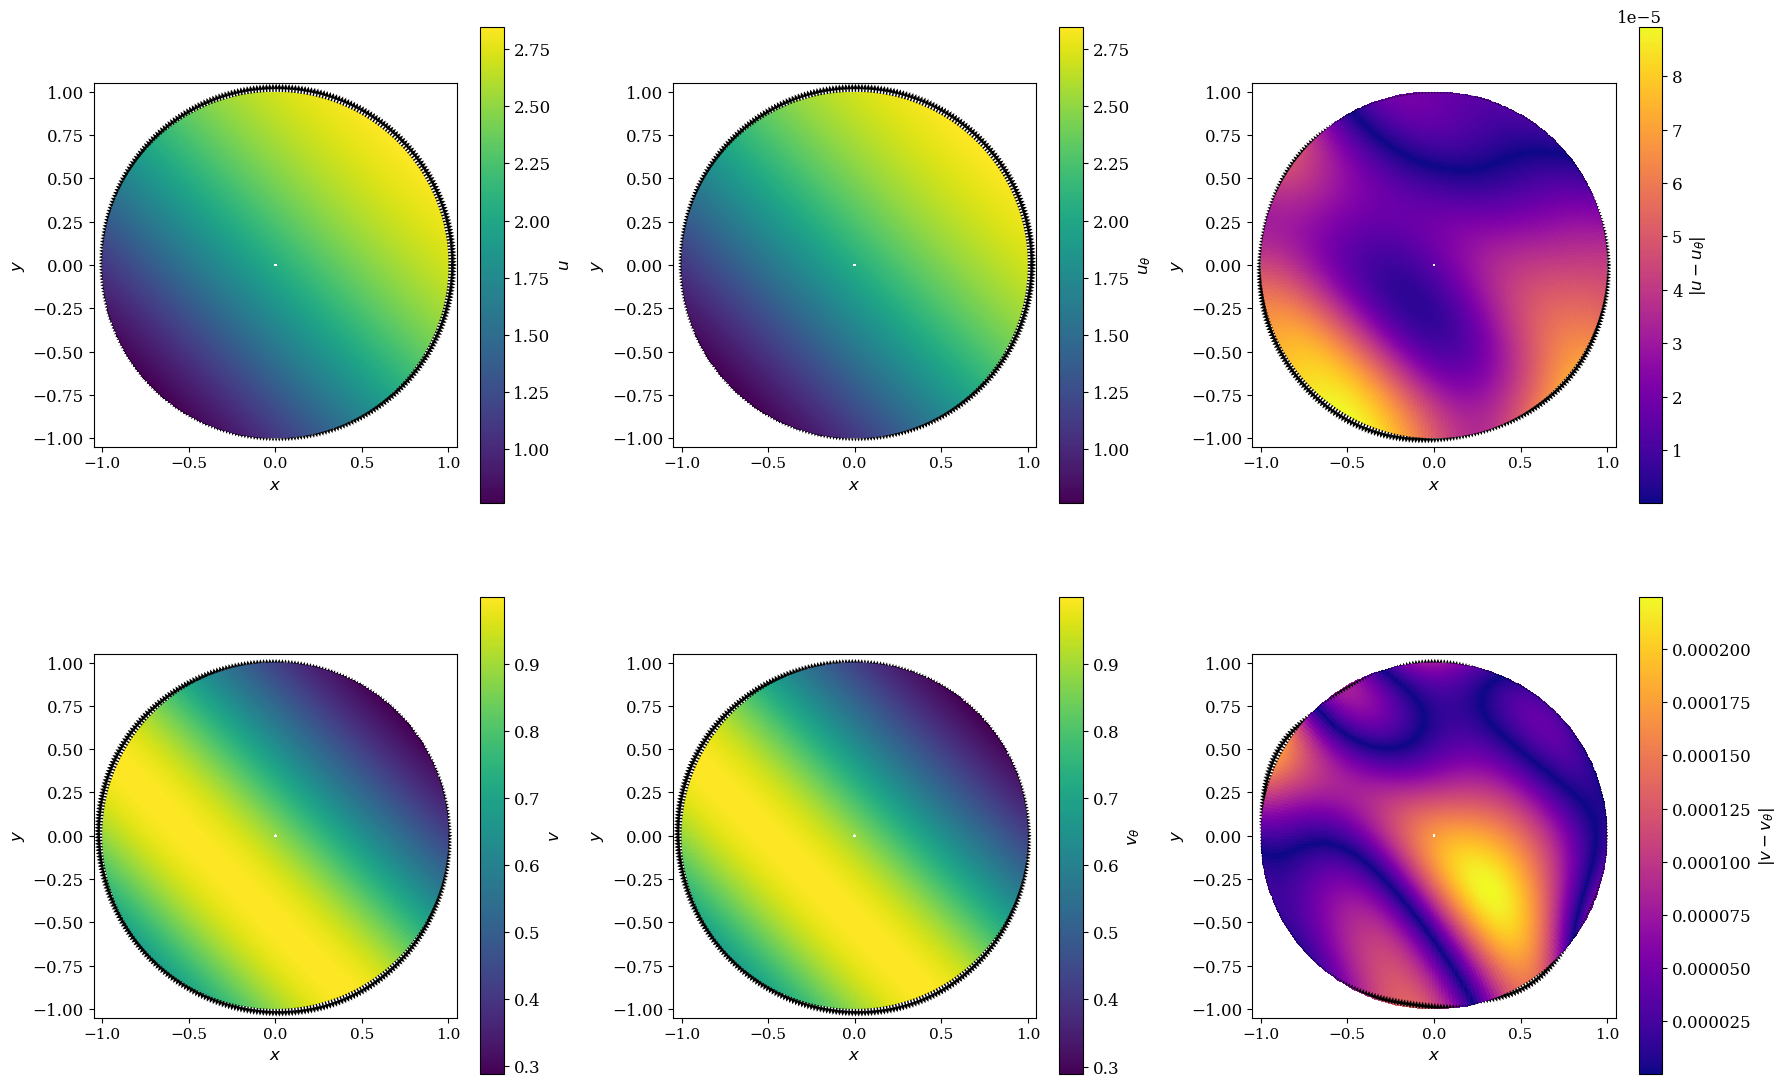


Computing errors and plotting for t = 0.75
  [Erreurs Relatives - INTÉRIEUR Ω à t=0.75]
    u -> L2 rel: 2.8305e-05 | H1 rel: 6.3370e-05 | Linf rel: 3.3313e-05
    v -> L2 rel: 1.7014e-04 | H1 rel: 4.5743e-04 | Linf rel: 2.4468e-04
  [Erreurs Relatives - BORD Γ à t=0.75]
    u -> L2 rel: 2.5592e-05 | H1 rel: 6.3853e-05 | Linf rel: 3.3313e-05
    v -> L2 rel: 1.4193e-04 | H1 rel: 6.9759e-04 | Linf rel: 1.9056e-04


C:\Users\Dellpc\AppData\Local\Temp\ipykernel_8720\1686394122.py:111: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(


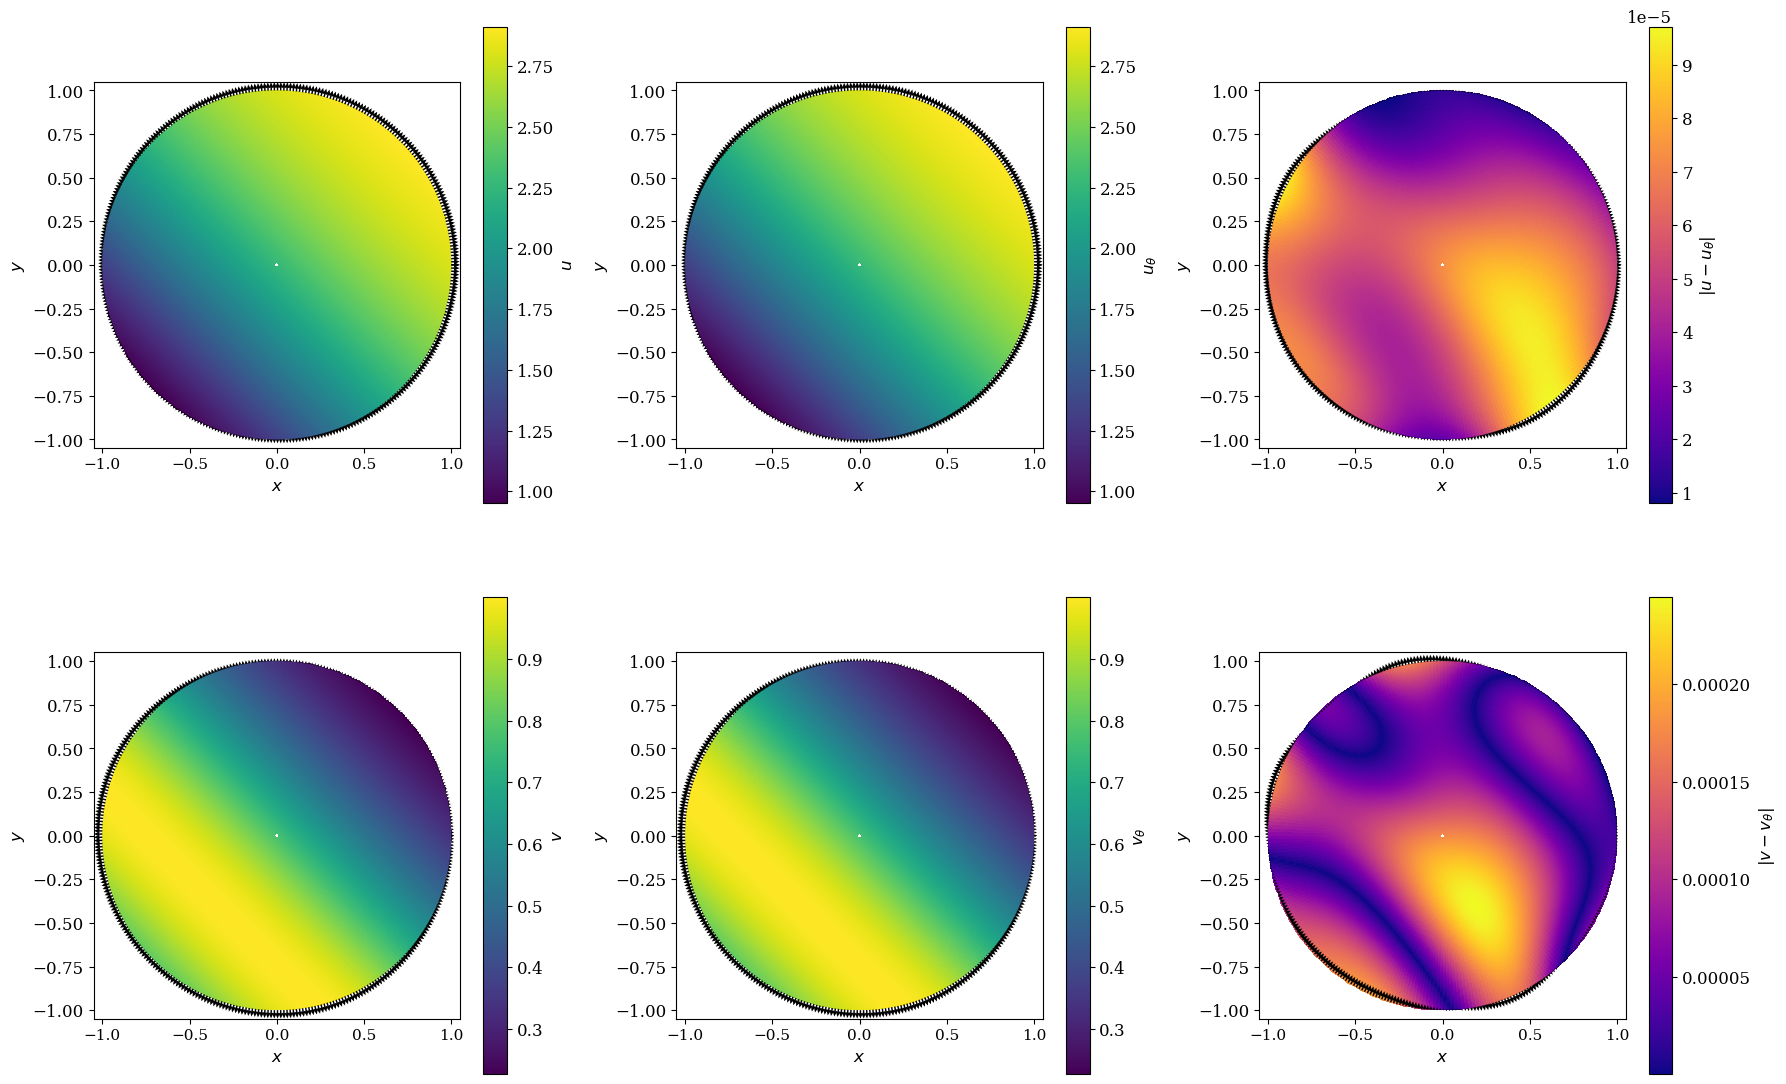


Computing errors and plotting for t = 1.0
  [Erreurs Relatives - INTÉRIEUR Ω à t=1.0]
    u -> L2 rel: 2.8264e-05 | H1 rel: 7.4916e-05 | Linf rel: 3.6127e-05
    v -> L2 rel: 1.2132e-04 | H1 rel: 6.4768e-04 | Linf rel: 2.3797e-04
  [Erreurs Relatives - BORD Γ à t=1.0]
    u -> L2 rel: 1.6611e-05 | H1 rel: 1.1895e-04 | Linf rel: 3.2023e-05
    v -> L2 rel: 1.6138e-04 | H1 rel: 1.0314e-03 | Linf rel: 2.3785e-04


C:\Users\Dellpc\AppData\Local\Temp\ipykernel_8720\1686394122.py:111: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im = ax.pcolormesh(


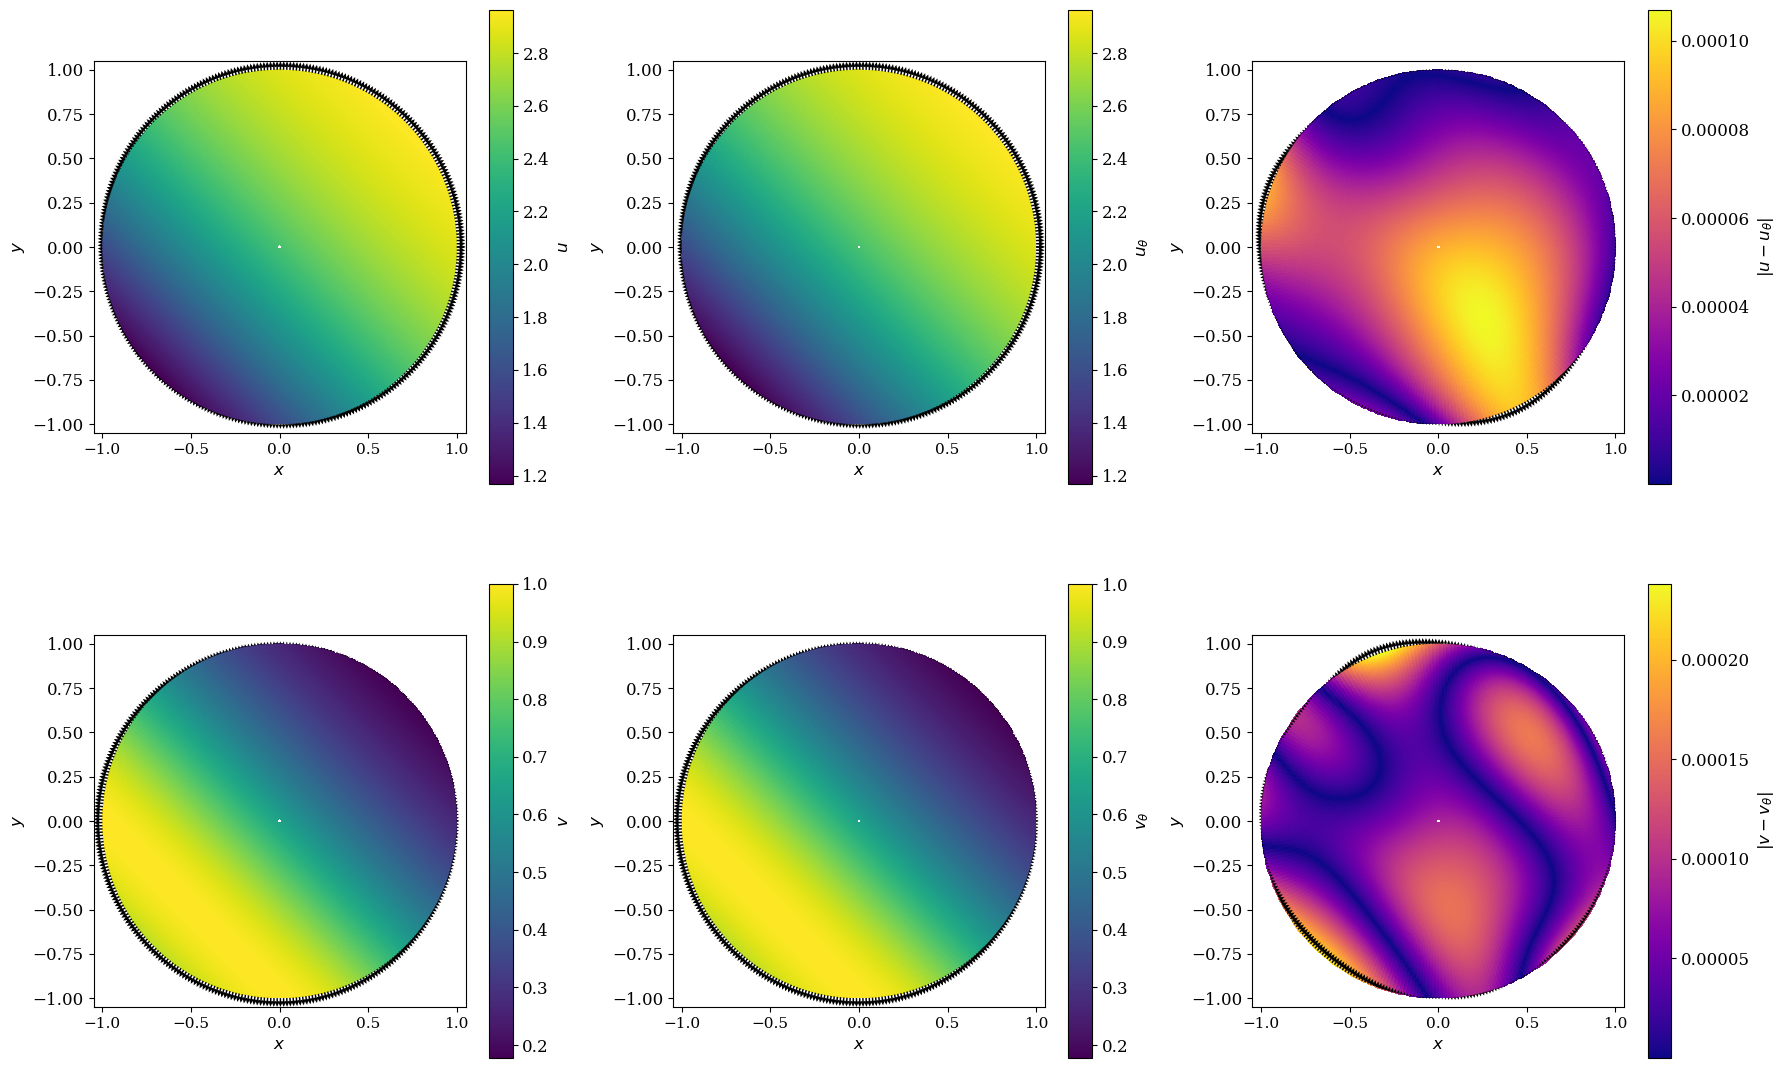

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


# =============================
# Paramètres généraux
# =============================
DTYPE = tf.float32
N_int = 300
N_b = 350          # ← increased for denser boundary arrows

t_values = [0.0, 0.25, 0.50, 0.75, 1.00]

# =============================
# Domaine intérieur (fixe)
# =============================
r_vals = np.linspace(0.01, 1.0, N_int)
theta_vals = np.linspace(0, 2*np.pi, N_int)

r, theta = np.meshgrid(r_vals, theta_vals)

x_int = r * np.cos(theta)
y_int = r * np.sin(theta)

# =============================
# Domaine du bord (fixe)
# =============================
theta_b = np.linspace(0, 2*np.pi, N_b)

x_b = np.cos(theta_b)
y_b = np.sin(theta_b)

# =============================
# Boucle sur les instants t
# =============================
for t_fix in t_values:

    print(f"\n==================================================")
    print(f"Computing errors and plotting for t = {t_fix}")
    print(f"==================================================")

    # =============================
    # Interior points preparation
    # =============================
    t_int = np.full_like(x_int, t_fix)
    X_int = np.stack([x_int.flatten(), y_int.flatten(), t_int.flatten()], axis=1)
    X_int_tf = tf.convert_to_tensor(X_int, dtype=DTYPE)

    # =============================
    # Boundary points preparation
    # =============================
    t_b_arr = np.full_like(x_b, t_fix)
    X_b = np.stack([x_b, y_b, t_b_arr], axis=1)
    X_b_tf = tf.convert_to_tensor(X_b, dtype=DTYPE)

    # =========================================================
    # CALCUL DES ERREURS RELATIVES VIA VOTRE FONCTION MAÎTRESSE
    # =========================================================
    L2_u_i, Linf_u_i, MSE_u_i, L2_v_i, Linf_v_i, MSE_v_i, H1_u_i, H1_v_i = \
        compute_errors_on_points(model, X_int_tf)
        
    L2_u_b, Linf_u_b, MSE_u_b, L2_v_b, Linf_v_b, MSE_v_b, H1_u_b, H1_v_b = \
        compute_errors_on_points(model, X_b_tf)

    # Affichage des erreurs relatives sous forme de tableau académique
    print(f"  [Erreurs Relatives - INTÉRIEUR Ω à t={t_fix}]")
    print(f"    u -> L2 rel: {L2_u_i:.4e} | H1 rel: {H1_u_i:.4e} | Linf rel: {Linf_u_i:.4e}")
    print(f"    v -> L2 rel: {L2_v_i:.4e} | H1 rel: {H1_v_i:.4e} | Linf rel: {Linf_v_i:.4e}")
    print(f"  [Erreurs Relatives - BORD Γ à t={t_fix}]")
    print(f"    u -> L2 rel: {L2_u_b:.4e} | H1 rel: {H1_u_b:.4e} | Linf rel: {Linf_u_b:.4e}")
    print(f"    v -> L2 rel: {L2_v_b:.4e} | H1 rel: {H1_v_b:.4e} | Linf rel: {Linf_v_b:.4e}")

    # =========================================================
    # ÉVALUATIONS DIRECTES DES DEUX SORTIES DU RÉSEAU (u et v)
    # =========================================================
    uv_pred_int = model(X_int_tf).numpy()
    uv_pred_b   = model(X_b_tf).numpy()

    # Extraction directe des composantes sans differentiation automatique
    u_pred_int = uv_pred_int[:, 0].reshape(N_int, N_int)
    v_pred_int = uv_pred_int[:, 1].reshape(N_int, N_int) # Directement la 2ème sortie !

    u_pred_b   = uv_pred_b[:, 0].flatten()
    v_pred_b   = uv_pred_b[:, 1].flatten() # Directement la 2ème sortie !

    # =========================================================
    # SOLUTIONS EXACTES ANALYTIQUES : 2*arctan(exp(x+y+t))
    # =========================================================
    # Intérieur
    exp_int = np.exp(x_int + y_int + t_fix)
    u_exact_int = 2.0 * np.arctan(exp_int)
    v_exact_int = 2.0 * exp_int / (1.0 + exp_int**2) # v_exact = ∂t(u_exact)

    # Bord
    exp_b = np.exp(x_b + y_b + t_fix)
    u_exact_b = 2.0 * np.arctan(exp_b)
    v_exact_b = 2.0 * exp_b / (1.0 + exp_b**2)

    # Profils d'erreurs absolues pour les cartes spatiales d'écarts
    u_err_int = u_exact_int - u_pred_int
    u_err_b   = u_exact_b   - u_pred_b

    v_err_int = v_exact_int - v_pred_int
    v_err_b   = v_exact_b   - v_pred_b

    # =========================================================
    # Fonction de tracé générique (Style d'origine conservé)
    # =========================================================
    def plot_field(ax, field_int, field_b, cmap, label):
        im = ax.pcolormesh(
            x_int, y_int, field_int,
            shading='auto', cmap=cmap
        )
        
        # --- MODIFIED PART: longer and clearer arrows ---
        scale_factor = 0.05 / (np.max(np.abs(field_b)) + 1e-10)   # ← increased length
        dx = scale_factor * field_b * x_b
        dy = scale_factor * field_b * y_b
        
        ax.quiver(
            x_b, y_b, dx, dy,
            color='black',
            angles='xy',
            scale_units='xy',
            scale=1,
            width=0.004,          # ← slightly thicker
            headwidth=3.5,
            headlength=4.0,
            headaxislength=3.5
        )
        
        ax.set_aspect('equal')
        ax.set_xlim(-1.05, 1.05)
        ax.set_ylim(-1.05, 1.05)
        ax.set_xlabel('$x$')
        ax.set_ylabel('$y$')
        fig.colorbar(im, ax=ax, shrink=0.8, label=label)

    # Initialisation de la figure (2 lignes, 3 colonnes)
    fig, axs = plt.subplots(2, 3, figsize=(18, 12))

    # ---------------------------------------------------------
    # LIGNE 1 : Tracés pour la fonction u
    # ---------------------------------------------------------
    # u — Exacte
    plot_field(axs[0, 0], u_exact_int, u_exact_b, 'viridis', r'$u$')

    # u — Approchée (PINN)
    plot_field(axs[0, 1], u_pred_int, u_pred_b, 'viridis', r'$u_\theta$')

    # u — Écart Absolu
    plot_field(axs[0, 2], np.abs(u_err_int), u_err_b, 'plasma', r'$|u-u_\theta|$')

    # ---------------------------------------------------------
    # LIGNE 2 : Tracés pour le champ v (Prédit par la 2ème sortie)
    # ---------------------------------------------------------
    # v — Exacte
    plot_field(axs[1, 0], v_exact_int, v_exact_b, 'viridis', r'$v$')

    # v — Approchée (PINN direct output)
    plot_field(axs[1, 1], v_pred_int, v_pred_b, 'viridis', r'$v_\theta$')

    # v — Écart Absolu
    plot_field(axs[1, 2], np.abs(v_err_int), v_err_b, 'plasma', r'$|v-v_\theta|$')

    plt.tight_layout()
    
    # Génère un export PDF vectoriel pour votre article
    plt.savefig(f"solution_snapshots_t_{t_fix:.2f}.pdf", format='pdf', bbox_inches='tight')
    plt.show()

In [20]:
def compute_generalization_error_bulk2(model, N_test=10000):
    """
    Generates N_test uniform random points inside the bulk cylinder Omega_T
    and computes the bulk generalization error E_G_OmegaT (with square root).
    """
    np.random.seed(42)
    # 1. Pure random uniform sampling inside the spacetime cylinder (r < 1, t in)
    r_rand = np.sqrt(np.random.rand(N_test, 1))
    theta_rand = 2.0 * np.pi * np.random.rand(N_test, 1)
    t_rand = np.random.rand(N_test, 1)
    
    x = tf.cast(r_rand * np.cos(theta_rand), tf.float64)
    y = tf.cast(r_rand * np.sin(theta_rand), tf.float64)
    t = tf.cast(t_rand, tf.float64)
    X_eval = tf.concat([x, y, t], axis=1)

    # 2. Gradient Tape for spatial gradients of u
    with tf.GradientTape() as tape:
        tape.watch(X_eval)
        u_pred, v_pred = compute_uv(model, tf.cast(X_eval, tf.float32))
        u_pred = tf.cast(u_pred, tf.float64)
        v_pred = tf.cast(v_pred, tf.float64)
        
    grad_u_pred = tape.gradient(u_pred, X_eval)
    u_x_pred = grad_u_pred[:, 0:1]
    u_y_pred = grad_u_pred[:, 1:2]

    # 3. Analytical Exact Solutions
    sum_term = tf.clip_by_value(x + y + t, -50.0, 50.0)
    exp_term = tf.math.exp(sum_term)
    denom = 1.0 + tf.math.square(exp_term)

    u_exact = 2.0 * tf.math.atan(exp_term)
    v_exact = 2.0 * exp_term / denom
    u_x_exact = v_exact
    u_y_exact = v_exact

    # 4. Compute error differences
    err_u = u_exact - u_pred
    err_v = v_exact - v_pred
    err_ux = u_x_exact - u_x_pred
    err_uy = u_y_exact - u_y_pred

    # 5. Continuous Integration via Monte Carlo (Volume of cylinder bulk = PI)
    vol_omega = np.pi

    term_u    = vol_omega * tf.reduce_mean(tf.math.square(err_u))
    term_grad = vol_omega * tf.reduce_mean(tf.math.square(err_ux) + tf.math.square(err_uy))
    term_v    = vol_omega * tf.reduce_mean(tf.math.square(err_v))

    total_bulk_error = np.sqrt(term_u + term_grad + term_v)
    
    return float(total_bulk_error), float(term_u), float(term_grad), float(term_v)


In [21]:
compute_generalization_error_bulk2(model, N_test=10000)

(0.00023408056942585167,
 6.086239983470099e-09,
 2.3876366970759383e-08,
 2.483110602850148e-08)

In [22]:
def compute_generalization_error_boundary(model, N_test=10000):
    """
    Generates N_test uniform random points along the boundary cylinder surface Gamma_T
    and computes the boundary generalization error E_G_GammaT (with square root).
    """
    np.random.seed(42)
    # 1. Pure random uniform sampling on the cylinder surface boundary (r = 1 fixed, t in)
    theta_b_rand = 2.0 * np.pi * np.random.rand(N_test, 1)
    t_b_rand = np.random.rand(N_test, 1)
    
    x = tf.cast(np.cos(theta_b_rand), tf.float64)
    y = tf.cast(np.sin(theta_b_rand), tf.float64)
    t = tf.cast(t_b_rand, tf.float64)
    X_eval = tf.concat([x, y, t], axis=1)

    # 2. Gradient Tape for spatial gradients of u
    with tf.GradientTape() as tape:
        tape.watch(X_eval)
        u_pred, v_pred = compute_uv(model, tf.cast(X_eval, tf.float32))
        u_pred = tf.cast(u_pred, tf.float64)
        v_pred = tf.cast(v_pred, tf.float64)
        
    grad_u_pred = tape.gradient(u_pred, X_eval)
    u_x_pred = grad_u_pred[:, 0:1]
    u_y_pred = grad_u_pred[:, 1:2]

    # 3. Project Tangential Gradient: nabla_Gamma = nabla - (nabla . n)n
    dnu_pred = u_x_pred * x + y * u_y_pred
    u_x_tan_pred = u_x_pred - dnu_pred * x
    u_y_tan_pred = u_y_pred - dnu_pred * y

    # 4. Analytical Exact Solutions
    sum_term = tf.clip_by_value(x + y + t, -50.0, 50.0)
    exp_term = tf.math.exp(sum_term)
    denom = 1.0 + tf.math.square(exp_term)

    u_exact = 2.0 * tf.math.atan(exp_term)
    v_exact = 2.0 * exp_term / denom
    u_x_exact = v_exact
    u_y_exact = v_exact

    # Exact Tangential boundary field gradients
    dnu_exact = u_x_exact * x + y * u_y_exact
    u_x_tan_exact = u_x_exact - dnu_exact * x
    u_y_tan_exact = u_y_exact - dnu_exact * y

    # 5. Compute error differences
    err_u = u_exact - u_pred
    err_v = v_exact - v_pred
    err_ux_tan = u_x_tan_exact - u_x_tan_pred
    err_uy_tan = u_y_tan_exact - u_y_tan_pred

    # 6. Continuous Integration via Monte Carlo (Surface Area of cylinder = 2 * PI)
    area_gamma = 2.0 * np.pi

    term_u    = area_gamma * tf.reduce_mean(tf.math.square(err_u))
    term_grad = area_gamma * tf.reduce_mean(tf.math.square(err_ux_tan) + tf.math.square(err_uy_tan))
    term_v    = area_gamma * tf.reduce_mean(tf.math.square(err_v))

    total_boundary_error = np.sqrt(term_u + term_grad + term_v)
    
    return float(total_boundary_error), float(term_u), float(term_grad), float(term_v)


In [23]:
compute_generalization_error_boundary(model, N_test=10000)

(0.00028546073897682046,
 1.2443295867122422e-08,
 2.7363860510436478e-08,
 4.168067711963352e-08)